# Introduction to the extended version of DiCE (Diverse Counterfactual Explanations)

[Mothilal et al. (2020)](https://dl.acm.org/doi/10.1145/3351095.3372850) introduce their method of generating counterfactual explanations considering _feasibility_, and _diversity_. [Guidotti and Ruggieri (2021)](https://link.springer.com/chapter/10.1007/978-3-030-88942-5_28), claim counterfactual explanations to be robust they should be similar for similar instances when they explain. In this study, in a search to improve the quality and reliability of the counterfactual explanations _robustness_ is found to be helpful and it also introduced in the optimization function.

DiCE-Extended is built upon the [DiCE (Diverse Counterfactual Explanations)](https://github.com/interpretml/DiCE) [(Mothilal et al. 2020)](https://dl.acm.org/doi/10.1145/3351095.3372850) framework by introducing a robustness term in the optimization function.

## Manipulated Optimization Function

The core enhancement in DiCE-Extended is the manipulated optimization function, designed to balance proximity, diversity, and feasibility of counterfactuals. The function is formulated as:

<a id="equation-1"></a>
\begin{equation}
\tag{1}
C(x) = \underset{c_1, ..., c_k}{\text{arg min}}
\frac{1}{2} \sum_{i=1}^{k} yloss(f(c_i), y) +
\frac{\lambda_1}{k} \sum_{i=1}^{k} dist(c_i, x) -
\lambda_2 \cdot dpp\_diversity(c_1, ..., c_k) -
\frac{\lambda_3}{k} \sum_{i=1}^{k} robustness(c_i, c_i')
\end{equation}

- **Proximity Loss**: The first term that averages the distance between generated counterfactuals and the original input ensure the counterfactuals to be as close as possible to the original input.
- **Diversity Loss**: Diversity of the counterfactual explanations is aquired by determinental point process of which loss is represented by the second term and it ensures that _k_ number of counterfactual explanations are generated.
- **Robustness Loss**: [Guidotti (2024)](https://link.springer.com/article/10.1007/s10618-022-00831-6) defines robustness as necessity of similar instances being explained by similar counterfactual explanations such that if $b(x_1)=b(x_2)=y$ then an explainer $f$ should generate counterfactuals $c_1$ and $c_2$ that are similar and can explain $x_1$ and $x_2$. The robustness term that is based on [Dice-Sørensen Coefficient](https://en.wikipedia.org/wiki/Dice-S%C3%B8rensen_coefficient), is adopted from [Bonasera and Carrizosa (2024)](
https://doi.org/10.48550/arXiv.2407.00843).

\begin{equation}
\tag{2}
Robustness(c_i, c_i') = \frac{2 * \lvert c_i \cap c_i' \rvert}{\lvert c_i \rvert + \lvert c_i' \rvert}
\end{equation}


By adjusting the weights $\lambda_1$, $\lambda_2$, $\lambda_3$ counterfactual explanations can be customised by specific needs.

### IMPORTANT NOTE

Some of the calculations in this notebook may yield slightly different results across runs. This variability is due to the stochastic nature of optimization processes, random initializations, and other computation dependent factors. Please keep this in mind when interpreting the results. For reproducibility, consider setting random seeds where applicable.

In [26]:
import sys
dice_path = "/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X"
sys.path.insert(0, dice_path)

In [27]:
import dice_ml_x
from dice_ml_x.utils import helpers, neuralnetworks
import pickle
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import itertools
from tqdm import tqdm
import pandas as pd
import random
import tensorflow as tf
import os
from collections import OrderedDict

In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
from dice_ml_x.benchmarking import Benchmarking
datasets = [(helpers.load_compas_dataset(), "twoyearrecid", "compas-recidivism"),
            (helpers.load_adult_income_dataset(), "income", "adult-income"),
             (helpers.load_lending_club_dataset(), "loan_status", "lending-club"),
             (helpers.load_german_credit_dataset(), "credit_risk", "german-credit")]
backends = ["sklearn", "PYT", "TF2"]
benchmarking = Benchmarking(datasets=datasets,
                            backends=backends)
benchmarking.load_and_train(batch_size=16)

Benchmarking:   0%|          | 0/12 [00:00<?, ?it/s]

the dataset is : compas-recidivism, the backend is : sklearn


Benchmarking:   8%|▊         | 1/12 [00:41<07:40, 41.85s/it, dataset=compas-recidivism, backend=sklearn]

the dataset is : compas-recidivism, the backend is : PYT


100%|██████████| 1/1 [01:01<00:00, 61.76s/it]


...

Diverse Counterfactuals found! total time taken: 00 min 11 sec
13/13 [==============================] - 0s 475us/step


the dataset is : german-credit, the backend is : TF2


Diverse Counterfactuals found! total time taken: 01 min 44 sec


Benchmarking: 100%|██████████| 12/12 [2:24:48<00:00, 724.03s/it, dataset=german-credit, backend=TF2] 

Diverse Counterfactuals found! total time taken: 01 min 34 sec


### Explainers' Loss Chart

During the counterfactual generation process we keep track of each losses computed for the optimization process. The chart below shows that the counterfactuals are optimized depending on various type of losses i.e., class loss, proximity loss, diversity loss, and robustness loss. The algorithm although reached a plateau around 50th iteration since the stopping criteria which is loss difference isn't met the loop keeps the calculations. The other stopping criteria is maximum number of iterations which is set to 5000. The chart is plotted without considering the weights for losses. 

In [29]:
with open('benchmarking_results_23_01_2025-01_05.pkl', 'rb') as res_file:
    benchmarking_results = pickle.load(res_file)

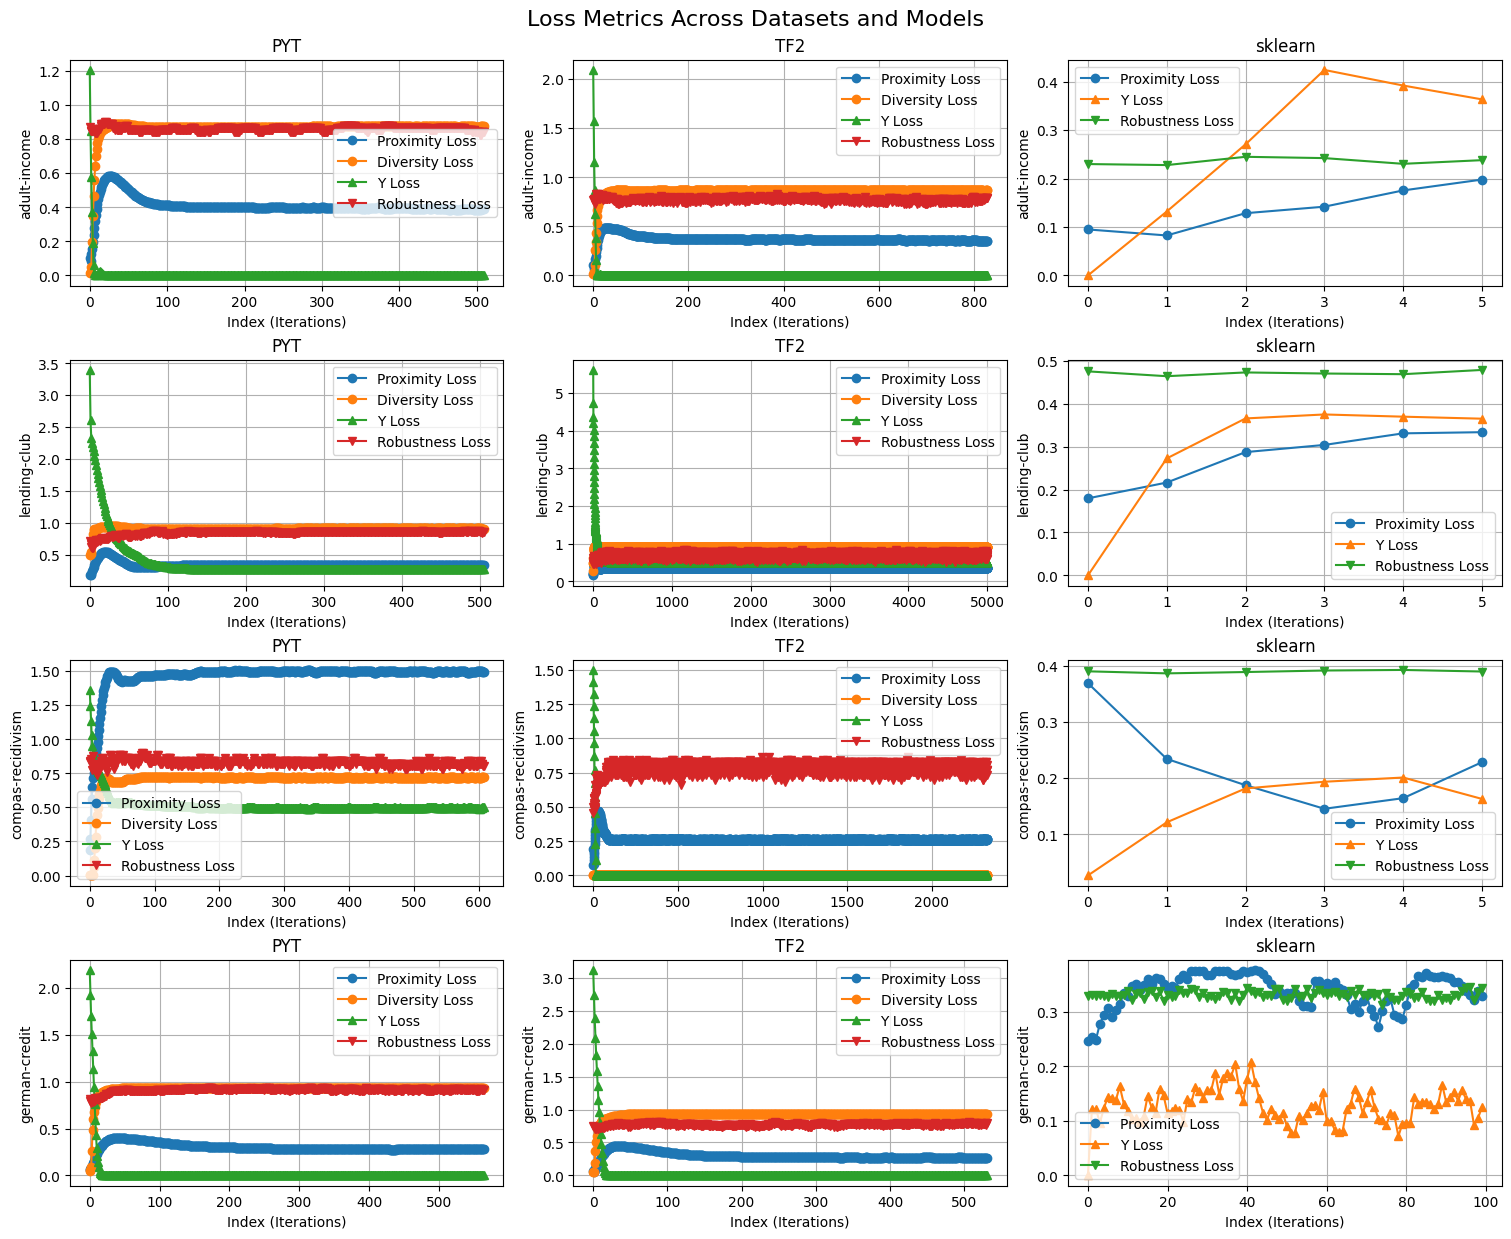

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_metrics_grid(benchmarking_results, datasets, backends, proximity_weight=1.0, diversity_weight=1.0, robustness_weight=1.0):
    num_datasets = len(datasets)
    num_backends = len(backends)

    fig, axes = plt.subplots(num_datasets, num_backends, figsize=(15, 12), constrained_layout=True)
    fig.suptitle("Loss Metrics Across Datasets and Models", fontsize=16, y=1.02)

    for i, dataset in enumerate(datasets):
        for j, backend in enumerate(backends):
            ax = axes[i, j]
            
            if backend in benchmarking_results[dataset]:
                loss_metrics = benchmarking_results[dataset][backend]['exp_history']

                proximity_loss = loss_metrics["proximity_loss"] if proximity_weight == 1.0 else [
                    loss * proximity_weight for loss in loss_metrics["proximity_loss"]
                ]

                robustness_loss = loss_metrics["robustness_loss"] if robustness_weight == 1.0 else [
                    loss * robustness_weight for loss in loss_metrics["robustness_loss"]
                ]
                if backend != 'sklearn':
                    diversity_loss = loss_metrics["diversity_loss"] if diversity_weight == 1.0 else [
                        loss * diversity_weight for loss in loss_metrics["diversity_loss"]
                    ]
                yloss = loss_metrics["y_loss"]

                ax.plot(proximity_loss, label="Proximity Loss", marker='o')
                if backend != 'sklearn':
                    ax.plot(diversity_loss, label="Diversity Loss", marker='o')
                ax.plot(yloss, label="Y Loss", marker='^')

                ax.plot(robustness_loss, label="Robustness Loss", marker='v')

            ax.set_title(backend)
            ax.set_xlabel("Index (Iterations)")
            ax.set_ylabel(dataset)
            ax.legend()
            ax.grid()

    plt.show()

datasets = ['adult-income', 'lending-club', 'compas-recidivism', 'german-credit']
backends = ['PYT', 'TF2', 'sklearn']
plot_loss_metrics_grid(benchmarking_results, datasets, backends)

In [30]:
backends = ['sklearn', 'PYT', 'TF2']
def load_torch_model(model_path, in_features):
    dummy_state_dict = torch.load(model_path)
    dummy_state_dict = {f'model.{key}': value for key, value in dummy_state_dict.items()}
    model = neuralnetworks.PYTModel(in_features)
    model.load_state_dict(dummy_state_dict)
    return model

def load_tensorflow_model(model_path):
    model = neuralnetworks.TF2Model()
    model.load_weights(model_path)
    return model

dataset_names = [
    "compas-recidivism",
    "adult-income",
    "lending-club",
    "german-credit"
]
models = {}
for name in dataset_names:
    models[name] = {}
    for backend in backends:
        if backend == 'sklearn':
            models[name][backend] = benchmarking_results[name][backend]['model']
        elif backend == 'PYT':
            model_path = benchmarking_results[name][backend]['model_path']
            print("model path for pyt -> ", model_path)
            num_features = benchmarking_results[name][backend]['metrics']['num_features']
            models[name][backend] = load_torch_model(model_path, num_features)
        elif backend == 'TF2':
            model_path = benchmarking_results[name][backend]['model_path']
            print("model_path for tf 2 -> ", model_path)
            models[name][backend] = load_tensorflow_model(model_path)

model path for pyt ->  benchmarking_artefact/compas-recidivism_PYT_model.pth
model_path for tf 2 ->  benchmarking_artefact/compas-recidivism_TF2_model
model path for pyt ->  benchmarking_artefact/adult-income_PYT_model.pth
model_path for tf 2 ->  benchmarking_artefact/adult-income_TF2_model
model path for pyt ->  benchmarking_artefact/lending-club_PYT_model.pth
model_path for tf 2 ->  benchmarking_artefact/lending-club_TF2_model
model path for pyt ->  benchmarking_artefact/german-credit_PYT_model.pth
model_path for tf 2 ->  benchmarking_artefact/german-credit_TF2_model


In [6]:
datasets = [(helpers.load_compas_dataset(), "twoyearrecid", "compas-recidivism"),
            (helpers.load_adult_income_dataset(), "income", "adult-income"),
             (helpers.load_lending_club_dataset(), "loan_status", "lending-club"),
             (helpers.load_german_credit_dataset(), "credit_risk", "german-credit")]
backends = ['TF2']
root_folder = 'cfe_datasets'
os.environ["TQDM_DISABLE"] = "1"
if not os.path.exists(root_folder):
    os.makedirs(root_folder)

cfe_datasets = {}

pbar = tqdm(datasets, desc="Generating counterfactual datasets...")

for df, target_name, df_name in pbar:
    target_col = df[target_name]
    train_dataset, test_dataset, y_train, y_test = train_test_split(df, target_col, test_size=0.2,
                                                                        random_state=42, stratify=target_col)
    cont_feats = df.select_dtypes(include=[np.number]).columns.difference([target_name])
    d = dice_ml_x.Data(dataframe=train_dataset, continuous_features=list(cont_feats), outcome_name=target_name)
    x_test = test_dataset.drop(columns=[target_name])
    

    for backend in backends:
        file_path = os.path.join(root_folder, f"{df_name}_{backend}_cfe.csv")

        if os.path.isfile(file_path):
            existing_df = pd.read_csv(file_path)
            num_rows = len(existing_df)
            if num_rows >= 1000:
                print(f"Skipping {df_name} for the backend {backend} because it already exists and have {num_rows} rows.")
                continue
        else:
            existing_df = pd.DataFrame()
            
        print(f"Processing {df_name} with {backend} ...")

        model_options = OrderedDict(model=models[df_name][backend], backend=backend)
        method = 'genetic' if backend == 'sklearn' else 'gradient'

        if backend != 'sklearn':
            model_options['func'] = 'ohe-min-max'
            if backend == 'PYT':
                model_options['model'] = models[df_name][backend].model

        m = dice_ml_x.Model(**model_options)
        exp = dice_ml_x.DiceX(d, m, method=method)

        if backend == 'PYT':
            x_test_ohe_vector = torch.tensor(d.get_ohe_min_max_normalized_data(x_test).values, dtype=torch.float32)
        elif backend == 'TF2':
            x_test_ohe_vector = tf.constant(d.get_ohe_min_max_normalized_data(x_test).values, dtype=tf.float32)
        
        if backend == 'PYT':
            _0_d_indices = np.where(m.model(x_test_ohe_vector) < 0.5)[0].tolist()
        elif backend == 'TF2':
            _0_d_indices = np.where(m.model.predict(x_test_ohe_vector) < 0.5)[0].tolist()
        else:
            _0_d_indices = np.where(m.model.predict(x_test) < 0.5)[0].tolist()

        _1_d_indices = list((set(range(len(x_test)))) - set(list(_0_d_indices)))

        random.shuffle(_0_d_indices)
        random.shuffle(_1_d_indices)

        if not existing_df.empty:
            count_class_0 = len(existing_df.loc[existing_df[target_name] < 0.5])
            count_class_1 = len(existing_df.loc[existing_df[target_name] >= 0.5])
        else:
            count_class_0, count_class_1 = 0, 0

        target_count = 500
        
        cfe_dataset_list = []
  
        while count_class_0 < target_count or count_class_1 < target_count:
            try:
                if count_class_0 < target_count:
                    rand_idx = random.choice(_0_d_indices)
                else:
                    rand_idx = random.choice(_1_d_indices)

                x = x_test[rand_idx : rand_idx + 1]

                if backend == 'PYT':
                    x_ohe = torch.tensor(d.get_ohe_min_max_normalized_data(x).values, dtype=torch.float32)
                    desired_class = int(m.model(x_ohe) >= 0.5)
                elif backend == 'TF2':
                    x_ohe = tf.constant(d.get_ohe_min_max_normalized_data(x).values, dtype=tf.float32)
                    desired_class = int(m.model.predict(x_ohe) >= 0.5)
                else:
                    desired_class = int(m.model.predict(x) >= 0.5)

                if (desired_class == 0 and count_class_0 >= target_count) or \
                (desired_class == 1 and count_class_1 >= target_count):
                    continue
            
                dice_exp = exp.generate_counterfactuals(
                    x, total_CFs=5, desired_class=desired_class, robustness_weight=0.4
                )

                cfe_sample = dice_exp.to_dataframe()

                if desired_class == 0:
                    count_class_0 += 5
                else:
                    count_class_1 += 5

                cfe_dataset_list.append(cfe_sample)
                
                if len(cfe_dataset_list) % 2 == 0:
                    if os.path.isfile(file_path):
                        existing_df = pd.read_csv(file_path)
                    else:
                        existing_df = pd.DataFrame()
                    
                    combined_df = pd.concat(cfe_dataset_list + [existing_df], ignore_index=True)
                
                    combined_df.to_csv(file_path, index=False)
                    print(f"{df_name} - {backend}, {len(combined_df)} counterfactuals are saved to {file_path}")
                    cfe_dataset_list = []

                pbar.set_postfix(OrderedDict(backend=backend, dataset=df_name,
                                            sample_count_class_0=count_class_0,
                                            sample_count_class_1=count_class_1))
                pbar.update(1)
            except Exception as e:
                print(f"Couldn't generate counterfactuals for {df_name}, {backend}")
                continue
        

Generating counterfactual datasets...:   0%|          | 0/4 [00:00<?, ?it/s]

Skipping compas-recidivism for the backend TF2 because it already exists and have 1000 rows.
Skipping adult-income for the backend TF2 because it already exists and have 1000 rows.
Processing lending-club with TF2 ...
1/1 [==============================] - 0s 8ms/step


Generating counterfactual datasets...:  25%|██▌       | 1/4 [02:42<08:06, 162.28s/it, backend=TF2, dataset=lending-club, sample_count_class_0=502, sample_count_class_1=293]

Diverse Counterfactuals found! total time taken: 01 min 16 sec
1/1 [==============================] - 0s 9ms/step


Generating counterfactual datasets...:  50%|█████     | 2/4 [05:55<06:00, 180.43s/it, backend=TF2, dataset=lending-club, sample_count_class_0=502, sample_count_class_1=298]

...

Diverse Counterfactuals found! total time taken: 01 min 49 sec
german-credit - TF2, 990 counterfactuals are saved to cfe_datasets/german-credit_TF2_cfe.csv
1/1 [==============================] - 0s 9ms/step


Generating counterfactual datasets...: 245it [3:47:56, 86.39s/it, backend=TF2, dataset=german-credit, sample_count_class_0=500, sample_count_class_1=495]

Diverse Counterfactuals found! total time taken: 02 min 09 sec
1/1 [==============================] - 0s 9ms/step


Generating counterfactual datasets...: 100%|██████████| 4/4 [3:48:28<00:00, 3427.08s/it, backend=TF2, dataset=german-credit, sample_count_class_0=500, sample_count_class_1=500]

Diverse Counterfactuals found! total time taken: 00 min 29 sec
german-credit - TF2, 1000 counterfactuals are saved to cfe_datasets/german-credit_TF2_cfe.csv


In [7]:
# Load datasets if the cell above stopped at some point
file_names = os.listdir('cfe_datasets')
keys = [(f_name.split('_')[0], f_name.split('_')[1]) for f_name in file_names]
target_names = {'lending-club': 'loan_status', 'compas-recidivism': 'twoyearrecid',
                'adult-income': 'income', 'german-credit': 'credit_risk'}
cfe_datasets = {}
for key, f_name in zip(keys, file_names):
    new_key = key + (target_names[key[0]],)
    cfe_datasets[new_key] = pd.read_csv(os.path.join('cfe_datasets', f_name))

In [8]:
# Convert target column to binary (0 or 1 depending on whether its value is greater or less than 0.5)
for (df_name, backend_name, target_name), cfe_dataset in cfe_datasets.items():
    cfe_dataset[target_name] = np.where(cfe_dataset[target_name] < 0.5, 0, 1)

In [9]:
# Train 12 models for each dataset and backend
from dice_ml_x.benchmarking import Benchmarking
artefact_path = 'cfe_models'
if not os.path.exists(artefact_path):
    os.makedirs(artefact_path)
cfe_model_results = {}
pbar = tqdm(cfe_datasets.items())
benchmarking = Benchmarking(None, None)
for (df_name, backend_name, target_name), cfe_dataset in pbar:
    cont_feats = cfe_dataset.select_dtypes(include=[np.number]).columns.difference([target_name])
    x_train_transformed, x_test_transformed, train_df, test_df, y_train, y_test = benchmarking.preprocess_data(backend_name, cfe_dataset, cont_feats, target_name, 8)
    model = benchmarking.train_model(backend_name, x_train_transformed, x_test_transformed, y_train)
    if backend_name == "sklearn":
        model_metrics = benchmarking.compute_RF_metrics(model, x_test_transformed, y_test)
    elif backend_name == "PYT":
        model_metrics = benchmarking.compute_pytorch_metrics(model, x_test_transformed)
    elif backend_name == "TF2":
        model_metrics = benchmarking.compute_keras_metrics(model, x_test_transformed, y_test)

    key = (df_name, backend_name)
    cfe_model_results[key] = {
        'model_metrics': model_metrics
    }

    if backend_name == "PYT":
        model_path = os.path.join(artefact_path, f"{df_name}_{backend_name}_model.pth")
        torch.save(model.state_dict(), model_path)
        cfe_model_results[key]['model_path'] = model_path
    elif backend_name == "TF2":
        model_path = os.path.join(artefact_path, f"{df_name}_{backend_name}_model")
        model.save_weights(model_path, save_format='tf')    
        cfe_model_results[key]['model_path'] = model_path
    else:
        model_path = os.path.join(artefact_path, f"{df_name}_{backend_name}_model.pkl")
        with open(model_path, 'wb') as model_file:
            pickle.dump(model, model_file)
        cfe_model_results[key]['model_path'] = model_path
    pbar.set_postfix(dataset=df_name, backend=backend_name)
    pbar.update(1)
    
model_result_path = os.path.join(artefact_path, 'model_metrics_result.pkl')
with open(model_result_path, 'wb') as model_res_file:
    pickle.dump(cfe_model_results, model_res_file)
    

  8%|▊         | 1/12 [00:01<00:12,  1.17s/it, backend=PYT, dataset=adult-income]

25/25 [==============================] - 0s 439us/step


 83%|████████▎ | 10/12 [00:03<00:00,  3.81it/s, backend=PYT, dataset=compas-recidivism]   

25/25 [==============================] - 0s 361us/step


100%|██████████| 12/12 [00:04<00:00,  3.11it/s, backend=TF2, dataset=lending-club]     

25/25 [==============================] - 0s 375us/step


13it [00:05,  2.31it/s, backend=TF2, dataset=german-credit]                        

25/25 [==============================] - 0s 343us/step


100%|██████████| 12/12 [00:06<00:00,  1.89it/s, backend=sklearn, dataset=adult-income]


In [150]:
## Load the model metrics file generated by training models with counterfactuals datasets.
with open('cfe_models/model_metrics_result.pkl', 'rb') as cfe_model_metrics_file:
    cfe_model_results = pickle.load(cfe_model_metrics_file)

In [152]:
rows = []
for (dataset, backend), info in cfe_model_results.items():
    metrics = info['model_metrics']
    row = {
        'dataset': dataset,
        'backend': backend,
        'accuracy': round(metrics['accuracy'], 2),
        'f1_score': round(metrics['f1_score'], 2),
        'recall': round(metrics['recall'], 2),
        'precision': round(metrics['precision'], 2),
        'auc': round(metrics['auc'], 2)
    }
    rows.append(row)

df = pd.DataFrame(rows)

backend_order = {'sklearn': 0, 'PYT': 1, 'TF2': 2}
df['backend_priority'] = df['backend'].map(backend_order)
df_sorted = df.sort_values(by=['dataset', 'backend_priority'])
df_sorted = df_sorted.drop(columns=['backend_priority'])
df_sorted = df_sorted.reset_index()
df_sorted.drop(columns="index", inplace=True)
print(df_sorted)

              dataset  backend  accuracy  f1_score  recall  precision   auc
0        adult-income  sklearn      0.98      0.99    0.99       0.98  0.98
1        adult-income      PYT      0.99      0.99    1.00       1.00  1.00
2        adult-income      TF2      1.00      1.00    1.00       0.99  1.00
3   compas-recidivism  sklearn      1.00      1.00    1.00       1.00  1.00
4   compas-recidivism      PYT      1.00      1.00    1.00       1.00  1.00
5   compas-recidivism      TF2      1.00      1.00    1.00       1.00  1.00
6       german-credit  sklearn      0.97      0.97    0.97       0.97  0.97
7       german-credit      PYT      1.00      1.00    1.00       1.00  1.00
8       german-credit      TF2      1.00      1.00    1.00       1.00  1.00
9        lending-club  sklearn      0.92      0.92    0.87       0.98  0.92
10       lending-club      PYT      0.99      0.99    1.00       1.00  1.00
11       lending-club      TF2      0.99      0.99    0.98       1.00  0.99


In [ ]:
# metric functions
def compute_validity(C: pd.DataFrame, target_name: str) -> float:
    C[target_name] = np.where(C[target_name] < 0.5, 0, 1)
    if len(C) == 0:
        return 0.0
    return len(C.drop_duplicates()) / len(C)

def compute_mad(data_class: dice_ml_x.Data, normalized=False) -> dict:
    return data_class.get_valid_mads(normalized=normalized)

def compute_continuous_proximity(C: pd.DataFrame, x: pd.DataFrame, data_class: dice_ml_x.Data) -> float:
    mads = compute_mad(data_class)
    total_proximity = 0.0

    for feature in data_class.continuous_feature_names:
        diff = np.abs(C[feature] - x[feature].iloc[0])
        total_proximity += diff / mads[feature]

    return -np.mean(total_proximity)

def compute_continuous_proximity(C: pd.DataFrame, x: pd.DataFrame, data_class: dice_ml_x.Data) -> float:
    mads = compute_mad(data_class)
    normalized_diff = (np.abs(C[data_class.continuous_feature_names] - x[data_class.continuous_feature_names].iloc[0]) / 
                      np.array([mads[feature] for feature in data_class.continuous_feature_names]).reshape(1, -1))
    mean_per_CF = np.nanmean(normalized_diff, axis=1)
    return -np.mean(mean_per_CF)

def compute_categorical_proximity(C: pd.DataFrame, x: pd.DataFrame, data_class: dice_ml_x.Data) -> float:
    categorical_feats = data_class.categorical_feature_names
    if len(x) == 0 or len(categorical_feats) == 0:
        return 0.0
    x_values: pd.Series = x.iloc[0]
    diff_matrix: pd.DataFrame = C[categorical_feats] != x_values[categorical_feats]
    diff_count: pd.Series = diff_matrix.sum(axis=1)
    d_cat = len(categorical_feats)

    average_distance = diff_count.mean() / (d_cat * len(C)) if d_cat > 0 else 0.0

    return 1 - average_distance

def compute_continuous_diversity(C: pd.DataFrame, data_class: dice_ml_x.Data) -> float:
    cont_feats = data_class.continuous_feature_names

    if isinstance(C, pd.DataFrame):
        X = C[cont_feats].values
    else:
        X = C

    k, d = X.shape

    if k < 2 or d == 0:
        return 0.0
    
    mad_dict = compute_mad(data_class)
    mad_vector = np.array([
        mad_dict[feature] if mad_dict[feature] != 0 else 1.0
        for feature in cont_feats
    ]).reshape(1, d)
    
    diff = np.abs(X[:, None, :] - X[None, :, :])
    normalized_diff = diff / mad_vector

    pairwise_dist = np.mean(normalized_diff, axis=2)
    triu_indices = np.triu_indices(k, k=1)
    if len(triu_indices[0]) == 0:
        return 0.0
    average_distance = np.mean(pairwise_dist[triu_indices])
    return average_distance

def compute_continuous_diversity(C: pd.DataFrame, data_class: dice_ml_x.Data) -> float:
    mads = compute_mad(data_class)  
    X = C[data_class.continuous_feature_names].values
    diff = np.abs(X[:, None, :] - X[None, :, :])
    normalized_diff = diff / np.array([mads[feature] for feature in data_class.continuous_feature_names]).reshape(1, 1, -1)
    pairwise_dist = np.nanmean(normalized_diff, axis=2)
    triu_indices = np.triu_indices(len(C), k=1)
    return np.mean(pairwise_dist[triu_indices]) if len(triu_indices[0]) > 0 else 0.0

def compute_categorical_diversity(C: pd.DataFrame, data_class: dice_ml_x.Data) -> float:
    cat_feats = data_class.categorical_feature_names

    if isinstance(C, pd.DataFrame):
        X = C[cat_feats].values
    else:
        X = C
    
    k, d = X.shape

    if k < 2 or d == 0:
        return 0.0

    diff = (X[:, None, :] != X[None, :, :]).astype(np.float32)

    pairwise_dist = np.mean(diff, axis=2)
    triu_indices = np.triu_indices(k, k=1)
    if len(triu_indices[0]) == 0:
        return 0.0
    average_distance = np.mean(pairwise_dist[triu_indices])
    return average_distance

def compute_count_diversity(C: pd.DataFrame):
    if isinstance(C, pd.DataFrame):
        X = C.values
    else:
        X = C

    k, d = X.shape

    if X.size == 0 or k < 2 or d == 0:
        return 0.0
    
    diff = (X[:, None, :] != X[None, :, :]).astype(np.float32)
    triu_indices = np.triu_indices(k, k=1)
    total_diff = np.sum(diff[triu_indices[0], triu_indices[1], :])

    n_pairs = len(triu_indices[0])
    return total_diff / (n_pairs * d)

def compute_sparsity(C: pd.DataFrame, x: pd.DataFrame, data_class: dice_ml_x.Data) -> float:
    cont_feats = data_class.continuous_feature_names
    cont_CFs = C[cont_feats].to_numpy()
    cont_X = x[cont_feats].to_numpy()

    k, d = cont_CFs.shape

    diff = (cont_CFs != cont_X[0])

    num_changed = diff.sum()

    return 1 - (num_changed / (k * d))

def do_perturbation(x_ohe: pd.DataFrame, data_class: dice_ml_x.Data):
        cat_cols = data_class.get_encoded_categorical_feature_indexes()
        cat_cols = [col for group in cat_cols for col in group]
        x_tensor = torch.tensor(x_ohe.values, dtype=torch.float32)
        
        continuous_feature_indexes = list(set(list(range(len(x_ohe.columns)))) - set(cat_cols))
        categorical_feature_indexes = data_class.get_encoded_categorical_feature_indexes()
        if continuous_feature_indexes:
            
            continuous_slice = x_tensor[:, continuous_feature_indexes]
            noise = continuous_slice * 0.1
            noise_mask = torch.zeros_like(x_tensor)
            noise_mask[:, continuous_feature_indexes] = noise
            x_tensor = x_tensor + noise_mask

        if categorical_feature_indexes:
            for cat_cols in categorical_feature_indexes:
                cat_slice = x_tensor[:, cat_cols]
                sample_size = cat_slice.shape[0]
                num_cats = cat_slice.shape[1]

                rand_idx = torch.randint(low=0, high=num_cats, size=(sample_size, ))

                cat_slice_perturbed = torch.nn.functional.one_hot(rand_idx, num_classes=num_cats).float()

                cat_mask = torch.zeros_like(x_tensor)
                cat_mask[:, cat_cols] = cat_slice_perturbed
                x_perturbed = x_tensor + cat_mask
        return x_perturbed

def generate_perturbations(x_ohe: pd.DataFrame, model: any, data_class: dice_ml_x.Data,
                           max_iter=100, tol=1e-3, gamma=1e-2):
        x_ohe_tensor = torch.tensor(x_ohe.values, dtype=torch.float32, requires_grad=True)
        x_perturbed = do_perturbation(x_ohe, data_class)
        perturbation_optimizer = torch.optim.Adam([x_perturbed], lr=1e-3)

        prev_loss = np.inf
        for _ in range(max_iter):
            with torch.no_grad():
                model.model.eval()
                pred_i = model.model(x_ohe_tensor)
                pred_i_prime = model.model(x_perturbed)
            class_loss = torch.mean((pred_i - pred_i_prime) ** 2)
            distance = torch.norm(x_perturbed - x_ohe_tensor, p=2)
            loss = class_loss + gamma * distance

            perturbation_optimizer.zero_grad()
            loss.backward()

            perturbation_optimizer.step()
            if abs(loss.item() - prev_loss) < tol:
                break
            prev_loss = loss.item()
        return x_perturbed.detach()

def compute_robustness(C: pd.DataFrame, x: pd.DataFrame, data_class: dice_ml_x.Data,
                       explainer: dice_ml_x.DiceX, exp_options: OrderedDict, model: any,
                       target_name: str) -> float:
    x_ohe = data_class.get_ohe_min_max_normalized_data(x)
    x_prime_ohe_tensor = generate_perturbations(x_ohe, model, data_class)
    x_prime_decoded = data_class.get_decoded_data(x_prime_ohe_tensor.numpy())
    x_prime = data_class.get_inverse_ohe_min_max_normalized_data(x_prime_decoded)
    C_prime = explainer.generate_counterfactuals(x_prime, **exp_options)
    C_prime = C_prime.to_dataframe()
    na_cols = C_prime.columns[C_prime.isna().any().tolist()].tolist()
    C_prime[na_cols] = C_prime[na_cols].fillna(x_prime[na_cols].iloc[0])
    C_prime[target_name] = (C_prime[target_name] >= 0.5).astype(int)
    C_ohe_tensor = torch.tensor(d.get_ohe_min_max_normalized_data(C).values, dtype=torch.float32)
    C_prime_ohe_tensor = torch.tensor(d.get_ohe_min_max_normalized_data(C_prime).values, dtype=torch.float32)
    return torch.mean(torch.cdist(C_ohe_tensor, C_prime_ohe_tensor, p=2)).item()


In [32]:
METRIC_KEYS = [
    'validity',
    'cat_diversity',
    'cont_diversity',
    'cont_count_diversity',
    'cat_proximity',
    'cont_proximity',
    'sparsity',
    'robustness',
    'num_cfs',
    'iteration'
]

def empty_metrics_dict():
    return {key: [] for key in METRIC_KEYS}

def compute_all_metrics(cf_df, query_instance_with_target, query_instance, d, model, exp, exp_options, target_name, it):
    cf_df[target_name] = np.where(cf_df[target_name] < 0.5, 0, 1)
    metrics = {}
    metrics['validity'] = compute_validity(cf_df, target_name)
    metrics['cat_diversity'] = compute_categorical_diversity(cf_df, d)
    metrics['cont_diversity'] = compute_continuous_diversity(cf_df, d)
    metrics['cont_count_diversity'] = compute_count_diversity(cf_df)
    metrics['cat_proximity'] = compute_categorical_proximity(cf_df, query_instance_with_target, d)
    metrics['cont_proximity'] = compute_continuous_proximity(cf_df, query_instance_with_target, d)
    metrics['sparsity'] = compute_sparsity(cf_df, query_instance_with_target, d)
    metrics['robustness'] = compute_robustness(C=cf_df, x=query_instance,
                                               data_class=d, explainer=exp, exp_options=exp_options,
                                               model=model, target_name=target_name)
    metrics['num_cfs'] = len(cf_df)
    metrics['iteration'] = it
    metrics['cf_df'] = cf_df
    return metrics

datasets = [(helpers.load_compas_dataset(), "twoyearrecid", "compas-recidivism"),
            (helpers.load_adult_income_dataset(), "income", "adult-income"),
            (helpers.load_lending_club_dataset(), "loan_status", "lending-club"),
            (helpers.load_german_credit_dataset(), "credit_risk", "german-credit")]

backends = ['PYT']
comparison_results = {}

for df, target_name, df_name in tqdm(datasets, desc="Datasets"):
    comparison_results[df_name] = {}
    df_target = df[target_name]
    train_dataset, test_dataset, y_train, y_test = train_test_split(df, df_target, test_size=0.2,
                                                                    random_state=42, stratify=df_target)
    n = 500
    if df_name == "german-credit":
        n = 200

    test_dataset_samples = test_dataset.sample(n=n)

    x_test = test_dataset_samples.drop(columns=[target_name]).copy()

    cont_feats = df.select_dtypes(include=[np.number]).columns.difference([target_name]).tolist()

    d = dice_ml_x.Data(dataframe=train_dataset, continuous_features=cont_feats, outcome_name=target_name)

    for backend_name in tqdm(backends, desc=f"{df_name} Backends", leave=False):
        comparison_results[df_name][backend_name] = {}

        model_options = OrderedDict(model=models[df_name][backend_name], backend=backend_name)
        method = 'genetic' if backend_name == 'sklearn' else 'gradient'
        if backend_name != 'sklearn':
            model_options['func'] = 'ohe-min-max'
            if backend_name == 'PYT':
                model_options['model'] = models[df_name][backend_name].model

        m = dice_ml_x.Model(**model_options)
        exp1 = dice_ml_x.DiceX(d, m, method=method)

        algo_variants = {
            'diverse_cfs': {"algorithm": "DiverseCF", "diversity_weight": 1.0,
                            "proximity_weight": 0.5, "posthoc_sparsity_param": 0.0},
            'nodiverse_cfs': {"algorithm": "DiverseCF", "diversity_weight": 0.0,
                              "proximity_weight": 0.5, "posthoc_sparsity_param": 0.0},
            'randominit_cfs': {"algorithm": "RandomInitCF", "diversity_weight": 1.0,
                               "proximity_weight": 0.5, "posthoc_sparsity_param": 0.0},
            'diverse_cfs_sparse': {"algorithm": "DiverseCF", "diversity_weight": 1.0,
                                   "proximity_weight": 0.5, "posthoc_sparsity_param": 0.1},
            'nodiverse_cfs_sparse': {"algorithm": "DiverseCF", "diversity_weight": 0.0,
                                     "proximity_weight": 0.5, "posthoc_sparsity_param": 0.1},
            'randominit_cfs_sparse': {"algorithm": "RandomInitCF", "diversity_weight": 1.0,
                                      "proximity_weight": 0.5, "posthoc_sparsity_param": 0.1},
        }

        for variant in list(algo_variants.keys()) + ['single_cf']:
            comparison_results[df_name][backend_name][variant] = empty_metrics_dict()

        pbar = tqdm(algo_variants.items(), desc='Variants', leave=True)

        single_cf_found = False

        while single_cf_found == False:
            rand_idx = random.randrange(0, len(x_test))
            query_instance = x_test.iloc[[rand_idx]]
            query_instance_with_target = test_dataset_samples.iloc[[rand_idx]]

            
            exp_options = OrderedDict(
                total_CFs=1,
                desired_class='opposite',
                posthoc_sparsity_param=0.0,
                proximity_weight=0.5,
                diversity_weight=1.0,
                robustness_weight=5.0,
                algorithm='DiverseCF'
            )
            try:
                cf_obj = exp1.generate_counterfactuals(query_instance, **exp_options)

                cf_df = cf_obj.to_dataframe()
                metrics = compute_all_metrics(cf_df=cf_df, query_instance_with_target=query_instance_with_target,
                                            query_instance=query_instance, d=d, model=m,
                                            exp=exp1, exp_options=exp_options,
                                            target_name=target_name, it=1)
                for key in METRIC_KEYS:
                    comparison_results[df_name][backend_name]['single_cf'][key].append(metrics[key])
                single_cf_found = True
            except Exception as e:
                continue

        for variant, params in pbar:
            it = 1
            while it <= 10:
                exp1 = dice_ml_x.DiceX(d, m, method=method)
                rand_idx = random.randrange(0, len(x_test))
                query_instance = x_test.iloc[[rand_idx]]
                query_instance_with_target = test_dataset_samples.iloc[[rand_idx]] 
                total_CFs = it

                diversity_weight = float(params.get('diversity_weight', 1.0))
                proximity_weight = float(params.get('proximity_weight', 0.5))
                posthoc_sparsity_param = float(params.get('posthoc_sparsity_param', 0.0))
                algorithm = params.get('algorithm')
                
                exp_options = OrderedDict(
                    total_CFs=total_CFs,
                    algorithm=algorithm,
                    desired_class='opposite',
                    diversity_weight=diversity_weight,
                    proximity_weight=proximity_weight,
                    robustness_weight=5.0,
                    posthoc_sparsity_param=posthoc_sparsity_param
                )
                try:
                    cf_obj = exp1.generate_counterfactuals(
                        query_instances=query_instance,
                        **exp_options
                    )

                    cf_df = cf_obj.to_dataframe()
                    metrics = compute_all_metrics(cf_df=cf_df, query_instance_with_target=query_instance_with_target,
                                                query_instance=query_instance, d=d, model=m,
                                                exp=exp1, exp_options=exp_options,
                                                target_name=target_name, it=it)
                    for key in METRIC_KEYS:
                        comparison_results[df_name][backend_name][variant][key].append(metrics[key])
                    it += 1
                except Exception as e:
                    continue

        pbar.set_postfix(OrderedDict(backend=backend_name))
        pbar.update(1)

Datasets:   0%|          | 0/4 [00:00<?, ?it/s]

Variants:   0%|          | 0/6 [01:15<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  1.18it/s]


Diverse Counterfactuals found! total time taken: 00 min 00 sec




100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


Diverse Counterfactuals found! total time taken: 00 min 01 sec




100%|██████████| 1/1 [00:01<00:00,  1.38s/it]


...

Diverse Counterfactuals found! total time taken: 00 min 18 sec






100%|██████████| 1/1 [00:29<00:00, 29.60s/it]


Diverse Counterfactuals found! total time taken: 00 min 21 sec






100%|██████████| 1/1 [00:34<00:00, 34.59s/it]

Datasets: 100%|██████████| 4/4 [1:55:52<00:00, 1738.04s/it]

Diverse Counterfactuals found! total time taken: 00 min 16 sec


In [ ]:
# If you run the cell above uncomment the two lines below to save results into a pickle file
import pickle

# DANGER! Make sure you already run the cell above before uncommenting the following lines.
#with open("comparison_figure_1.pkl", "wb") as comp_file:
#    pickle.dump(comparison_results, comp_file)

with open("comparison_figure_1.pkl", "rb") as comp_file:
    comparison_results = pickle.load(comp_file)

In [ ]:
METRIC_KEYS = [
    'validity',
    'cat_diversity',
    'cont_diversity',
    'cont_count_diversity',
    'cat_proximity',
    'cont_proximity',
    'sparsity',
    'robustness',
    'num_cfs'
]

rows = []
for dataset, dataset_data in comparison_results.items():
    
    if 'PYT' not in dataset_data:
        continue
    pyt_data = dataset_data['PYT']

    for variant, metrics in pyt_data.items():
    
        iterations = metrics.get("iteration", list(range(1, len(metrics["validity"]) + 1)))
    
        for i, iter_val in enumerate(iterations):
            row = {
                "dataset": dataset,
                "backend": "PYT",
                "variant": variant,
                "iteration": iter_val
            }
    
            for key in METRIC_KEYS:
    
                row[key] = metrics[key][i] if i < len(metrics[key]) else None
            rows.append(row)

df_table = pd.DataFrame(rows)


df_table = df_table.sort_values(by=["dataset", "variant", "iteration"])
df_table[df_table['dataset'] == 'compas-recidivism']

,dataset,backend,variant,iteration,validity,cat_diversity,cont_diversity,cont_count_diversity,cat_proximity,cont_proximity,sparsity,robustness,num_cfs
0,compas-recidivism,PYT,diverse_cfs,1,1.000000,0.000000,0.000000,0.000000,1.000000,-1.853571,0.000000,0.366437,1
1,compas-recidivism,PYT,diverse_cfs,2,1.000000,0.666667,3.425000,0.500000,0.833333,-2.141071,0.250000,1.435604,2
2,compas-recidivism,PYT,diverse_cfs,3,1.000000,0.222222,3.766667,0.444444,0.703704,-2.875000,0.000000,2.326380,3
3,compas-recidivism,PYT,diverse_cfs,4,1.000000,0.333333,3.117857,0.416667,0.916667,-3.075000,0.000000,1.443765,4
4,compas-recidivism,PYT,diverse_cfs,5,1.000000,0.400000,3.128571,0.483333,0.920000,-3.636429,0.000000,1.562822,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,compas-recidivism,PYT,randominit_cfs_sparse,7,0.857143,0.000000,0.522789,0.285714,0.857143,-2.347449,0.071429,2.469544,7
57,compas-recidivism,PYT,randominit_cfs_sparse,8,0.500000,0.083333,0.202041,0.166667,0.953125,-0.914286,0.500000,1.862621,8
58,compas-recidivism,PYT,randominit_cfs_sparse,9,1.000000,0.388889,3.758333,0.523148,0.942387,-3.718254,0.000000,1.728065,9
59,compas-recidivism,PYT,randominit_cfs_sparse,10,0.400000,0.000000,0.012063,0.129630,0.966667,-1.300000,0.000000,1.102660,10


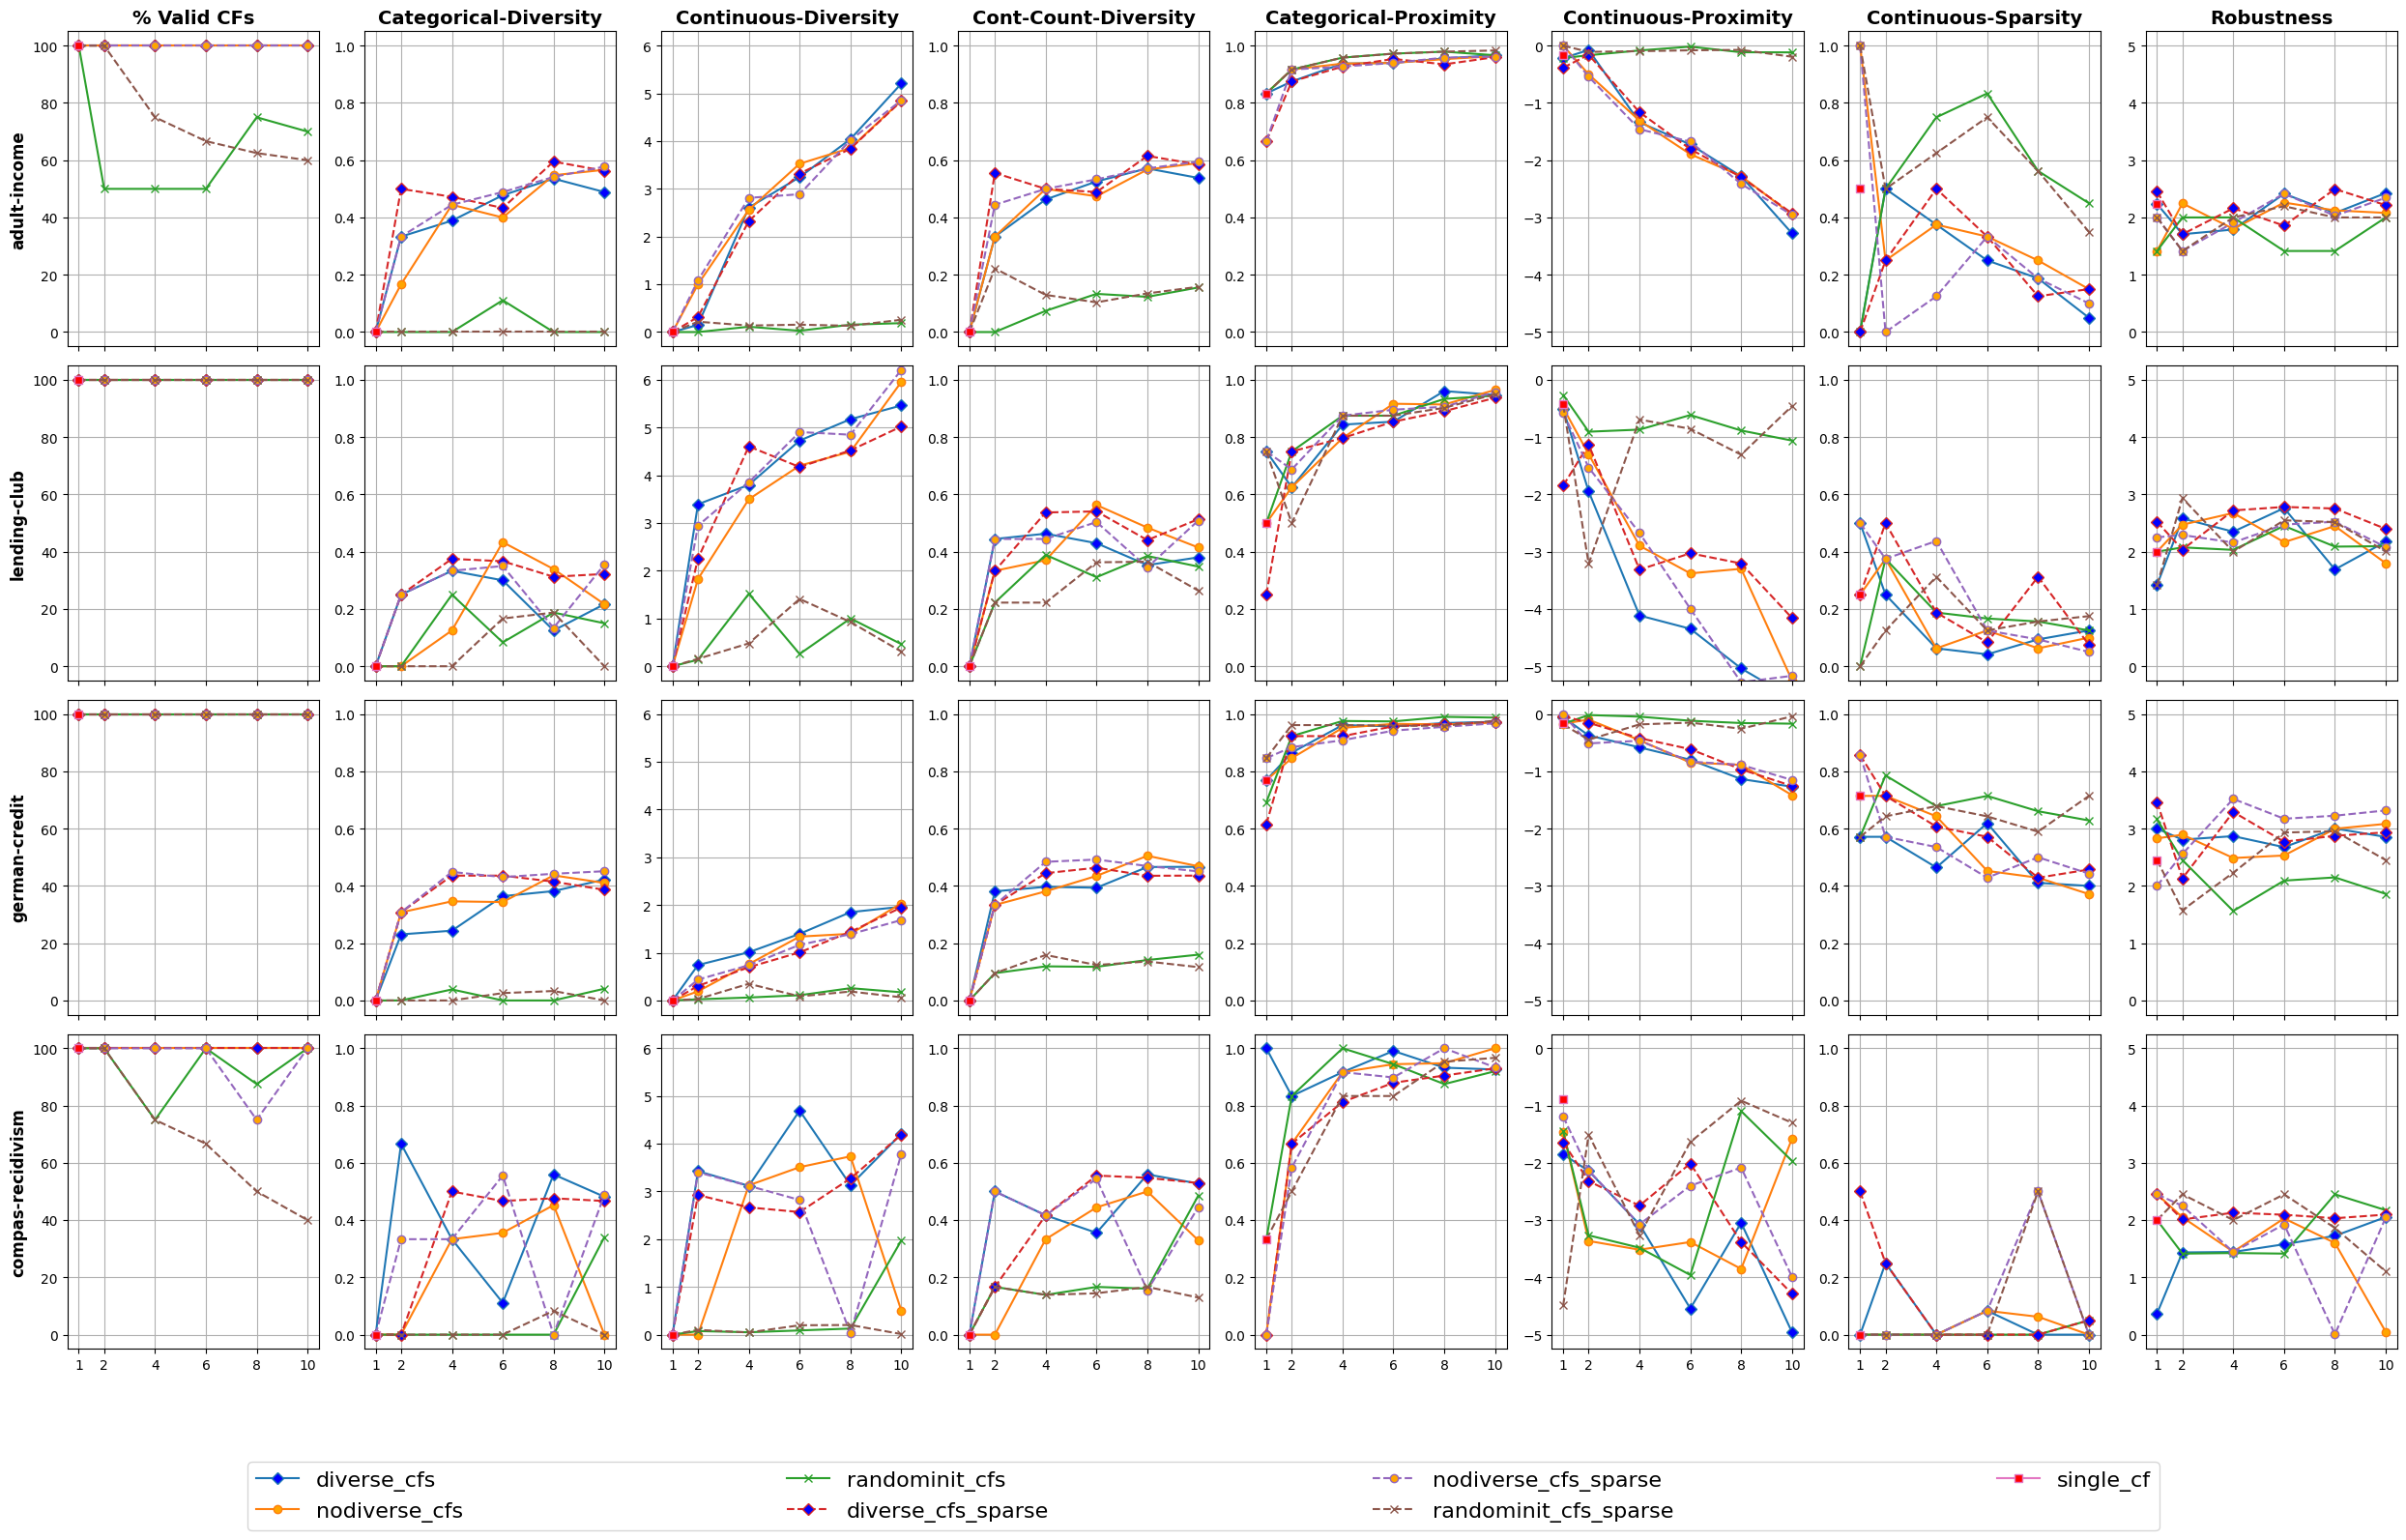

In [ ]:
import math

def normalize_list(values, target_min, target_max):
    obs_min = min(values)
    obs_max = max(values)
    if obs_max == obs_min:
        return [ (target_min + target_max) / 2.0 for _ in values ]
    scale = (target_max - target_min) / (obs_max - obs_min)
    return [ (v - obs_min) * scale + target_min for v in values ]

def add_margin(target_range, margin=0.05):
    tmin, tmax = target_range
    delta = tmax - tmin
    return (tmin - margin * delta, tmax + margin * delta)

target_ranges = {
    "validity": (0, 100),
    "cat_diversity": (0, 1),
    "cont_diversity": (0, 6),
    "cont_count_diversity": (0, 1),
    "cat_proximity": (0, 1),
    "cont_proximity": (-5, 0),
    "sparsity": (0, 1),
    "robustness": (0, 5)
}

line_styles = {
    "diverse_cfs": ('-', 'D', 'blue'),
    "diverse_cfs_sparse": ('--', 'D', 'blue'),
    "nodiverse_cfs": ('-', 'o', 'orange'),
    "nodiverse_cfs_sparse": ('--', 'o', 'orange'),
    "randominit_cfs": ('-', 'x', 'green'),
    "randominit_cfs_sparse": ('--', 'x', 'green'),
    "single_cf": ('-', 's', 'red')
}

metric_names = ['% Valid CFs', 'Categorical-Diversity', 'Continuous-Diversity',
                'Cont-Count-Diversity', 'Categorical-Proximity', 'Continuous-Proximity', 'Continuous-Sparsity', 'Robustness']

datasets_list = ['adult-income', 'lending-club', 'german-credit', 'compas-recidivism']

variants = list(comparison_results[datasets_list[2]]['PYT'].keys())


fig, axes = plt.subplots(nrows=len(datasets_list), ncols=len(target_ranges), 
                           figsize=(25, 16), sharex=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

iterations_to_show = [1, 2, 4, 6, 8, 10]

for row_idx, dataset in enumerate(datasets_list):
    if dataset not in comparison_results:
        continue
    if 'PYT' not in comparison_results[dataset]:
        continue
    pyt_data = comparison_results[dataset]['PYT']
    
    for col_idx, key in enumerate(target_ranges.keys()):
        ax = axes[row_idx, col_idx]
        for variant in variants:
            variant_data = pyt_data[variant]
            if key not in variant_data:
                continue

            y_values = variant_data[key]
            x_values = []
            y_plot =[]

            for i in iterations_to_show:
                if i <= len(y_values):
                    x_values.append(i) 
                    y_plot.append(y_values[i - 1])

            if not x_values:
                continue

            if key == "validity":
                
                norm_values = [v * 100 for v in y_plot]
                
            else:
                norm_values = y_plot

            linestyle, marker, marker_color = line_styles.get(variant, ('-', 'o', 'blue'))    
            ax.plot(x_values, norm_values, markerfacecolor=marker_color, linestyle=linestyle,
                    marker=marker, label=variant)
        
        ax.set_ylim(add_margin(target_ranges[key], margin=0.05))
        
        ax.set_xticks(iterations_to_show)
        if row_idx == len(datasets_list) - 1:
            ax.set_xticklabels(iterations_to_show, fontsize=10)
        else:
            ax.set_xticklabels([])

        if col_idx == 0:
            ax.set_ylabel(dataset, fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
    
        if row_idx == 0:
            ax.set_title(metric_names[col_idx], fontsize=14, fontweight='bold')
        
        ax.grid(True)

n_variants = len(variants)
ncol = math.ceil(n_variants / 2)
handles, labels = axes[-1, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=ncol, bbox_to_anchor=(0.1, -0.05, 0.8, 0.1), mode="expand", fontsize=16)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Results on counterfactual datasets

The counterfactual datasets generated with 4 datasets and 3 different counterfactual generation strategies is investigated in terms of validity, diversity, and robustness.

In [ ]:
import os
file_names = os.listdir('cfe_datasets')
keys = [(f_name.split('_')[0], f_name.split('_')[1]) for f_name in file_names]
target_names = {'lending-club': 'loan_status', 'compas-recidivism': 'twoyearrecid',
                'adult-income': 'income', 'german-credit': 'credit_risk'}
cfe_datasets = {}

for key, f_name in zip(keys, file_names):
    new_key = key + (target_names[key[0]],)
    cfe_datasets[new_key] = pd.read_csv(os.path.join('cfe_datasets', f_name))

# Convert target column to binary (0 or 1 depending on whether its value is greater or less than 0.5)
for (df_name, backend_name, target_name), cfe_dataset in cfe_datasets.items():
    cfe_dataset[target_name] = np.where(cfe_dataset[target_name] < 0.5, 0, 1)

In [83]:
def load_torch_model(model_path):
    print('model_path is -> ', model_path)
    dummy_state_dict = torch.load(model_path)
    dummy_state_dict = {f'model.{key}': value for key, value in dummy_state_dict.items()}
    in_features = dummy_state_dict['model.0.weight'].shape[1]
    model = neuralnetworks.PYTModel(in_features)
    model.load_state_dict(dummy_state_dict)
    return model

def load_tensorflow_model(model_path):
    model = neuralnetworks.TF2Model()
    model.load_weights(model_path)
    return model
root_dir = 'cfe_models'
file_names = [f_name for f_name in os.listdir(root_dir) if f_name.endswith(('pkl', 'pth', 'index')) and f_name != 'model_metrics_result.pkl']
keys = [(f_name.split('_')[0], f_name.split('_')[1]) for f_name in file_names if f_name.endswith(('pkl', 'pth', 'index')) and f_name != 'model_metrics_result.pkl']

dataset_names = [
    "compas-recidivism",
    "adult-income",
    "lending-club",
    "german-credit"
]

cfe_models = {'adult-income': {}, 'lending-club': {},
          'german-credit': {}, 'compas-recidivism': {}}

def pick_model(models, df_name, backend_name, root_dir, f_name):
    if backend_name == 'sklearn':
        model_path = os.path.join(root_dir, f_name)
        with open(model_path, 'rb') as sklearn_model_file:
            sklearn_model = pickle.load(sklearn_model_file)
        models[df_name][backend_name] = sklearn_model
    elif backend_name == 'PYT':
        model_path = os.path.join(root_dir, f_name)
        models[df_name][backend_name] = load_torch_model(model_path)
    elif backend_name == 'TF2':
        model_path = os.path.join(root_dir, f_name)
        models[df_name][backend_name] = load_tensorflow_model(model_path)


for (df_name, backend_name), f_name in zip(keys, file_names):
    print((df_name, backend_name), ' -> ', f_name)
    if df_name == 'adult-income':
        pick_model(cfe_models, df_name, backend_name, root_dir, f_name)
    elif df_name == 'lending-club':
        pick_model(cfe_models, df_name, backend_name, root_dir, f_name)
    elif df_name == 'german-credit':
        pick_model(cfe_models, df_name, backend_name, root_dir, f_name)
    elif df_name == 'compas-recidivism':
        pick_model(cfe_models, df_name, backend_name, root_dir, f_name)

('german-credit', 'TF2')  ->  german-credit_TF2_model.index
('german-credit', 'sklearn')  ->  german-credit_sklearn_model.pkl
('lending-club', 'sklearn')  ->  lending-club_sklearn_model.pkl
('lending-club', 'PYT')  ->  lending-club_PYT_model.pth
model_path is ->  cfe_models/lending-club_PYT_model.pth
('compas-recidivism', 'sklearn')  ->  compas-recidivism_sklearn_model.pkl
('adult-income', 'TF2')  ->  adult-income_TF2_model.index
('lending-club', 'TF2')  ->  lending-club_TF2_model.index
('adult-income', 'sklearn')  ->  adult-income_sklearn_model.pkl
('adult-income', 'PYT')  ->  adult-income_PYT_model.pth
model_path is ->  cfe_models/adult-income_PYT_model.pth
('german-credit', 'PYT')  ->  german-credit_PYT_model.pth
model_path is ->  cfe_models/german-credit_PYT_model.pth
('compas-recidivism', 'PYT')  ->  compas-recidivism_PYT_model.pth
model_path is ->  cfe_models/compas-recidivism_PYT_model.pth
('compas-recidivism', 'TF2')  ->  compas-recidivism_TF2_model.index


In [14]:
cfe_dfs_validity_results = {}
cfe_dfs_cont_diversity_results = {}
cfe_dfs_cat_diversity_results = {}
for (df_name, backend, target_name), cfe_dataset in cfe_datasets.items():
    cfe_dfs_validity_results[(df_name, backend)] = compute_validity(cfe_dataset, target_name)
    target_col = cfe_dataset[target_name]
    train_dataset, test_dataset, y_train, y_test = train_test_split(cfe_dataset, target_col, test_size=0.2,
                                                                    random_state=42, shuffle=True, stratify=target_col)
    cont_feats = cfe_dataset.select_dtypes(include=[np.number]).columns.difference([target_name]).tolist()
    data_class = dice_ml_x.Data(dataframe=train_dataset, continuous_features=cont_feats, outcome_name=target_name)
    cfe_dfs_cont_diversity_results[(df_name, backend)] = compute_continuous_diversity(cfe_dataset, data_class)
    cfe_dfs_cat_diversity_results[(df_name, backend)] = compute_categorical_diversity(cfe_dataset, data_class)
print(cfe_dfs_validity_results)
print(cfe_dfs_cont_diversity_results)
print(cfe_dfs_cat_diversity_results)


{('adult-income', 'PYT'): 0.972, ('compas-recidivism', 'TF2'): 0.897, ('lending-club', 'PYT'): 0.775, ('german-credit', 'sklearn'): 0.448, ('german-credit', 'PYT'): 0.48, ('compas-recidivism', 'sklearn'): 0.6595310907237513, ('compas-recidivism', 'PYT'): 0.579, ('lending-club', 'TF2'): 0.872, ('german-credit', 'TF2'): 0.992, ('adult-income', 'TF2'): 0.993, ('lending-club', 'sklearn'): 0.7715430861723447, ('adult-income', 'sklearn'): 0.8892245720040282}
{('adult-income', 'PYT'): 1.6209521743966184, ('compas-recidivism', 'TF2'): 1.8904749441570596, ('lending-club', 'PYT'): 2.312134057383002, ('german-credit', 'sklearn'): 1.2113180980971554, ('german-credit', 'PYT'): 1.421252279400414, ('compas-recidivism', 'sklearn'): 2.971019219395928, ('compas-recidivism', 'PYT'): 2.5050478079707146, ('lending-club', 'TF2'): 5.393457578471189, ('german-credit', 'TF2'): 1.373577800001462, ('adult-income', 'TF2'): 1.67765617045617, ('lending-club', 'sklearn'): 1.8304080335727058, ('adult-income', 'sklear

In [21]:
dummy_dict = {'adult-income': {}, 'lending-club': {},
               'german-credit': {}, 'compas-recidivism': {}}
for (df_name, backend_name), cont_result in cfe_dfs_cont_diversity_results.items():
    if df_name == 'adult-income':
        dummy_dict['adult-income'][backend_name] = round(cont_result, 2)
    elif df_name == 'lending-club':
        dummy_dict['lending-club'][backend_name] = round(cont_result, 2)
    elif df_name == 'german-credit':
        dummy_dict['german-credit'][backend_name] = round(cont_result, 2)
    elif df_name == 'compas-recidivism':
        dummy_dict['compas-recidivism'][backend_name] = round(cont_result, 2)
        
table_mkdwn = '| Dataset            | sklearn | PYT  | TF2  |\n'
table_mkdwn += '|--------------------|---------|------|------|\n'

for dataset, models in dummy_dict.items():
    table_mkdwn += f'| {dataset:<18} | {models["sklearn"]:.2f} | {models["PYT"]:.2f} | {models["TF2"]:.2f} |\n'

print(table_mkdwn)

| Dataset            | sklearn | PYT  | TF2  |
|--------------------|---------|------|------|
| adult_income       | 2.35 | 1.62 | 1.68 |
| lending-club       | 1.83 | 2.31 | 5.39 |
| german-credit      | 1.21 | 1.42 | 1.37 |
| compas-recidivism  | 2.97 | 2.51 | 1.89 |



In [22]:
dummy_dict = {'adult-income': {}, 'lending-club': {},
               'german-credit': {}, 'compas-recidivism': {}}
for (df_name, backend_name), cont_result in cfe_dfs_cat_diversity_results.items():
    if df_name == 'adult-income':
        dummy_dict['adult-income'][backend_name] = round(cont_result, 2)
    elif df_name == 'lending-club':
        dummy_dict['lending-club'][backend_name] = round(cont_result, 2)
    elif df_name == 'german-credit':
        dummy_dict['german-credit'][backend_name] = round(cont_result, 2)
    elif df_name == 'compas-recidivism':
        dummy_dict['compas-recidivism'][backend_name] = round(cont_result, 2)
        
table_mkdwn = '| Dataset            | sklearn | PYT  | TF2  |\n'
table_mkdwn += '|--------------------|---------|------|------|\n'

for dataset, models in dummy_dict.items():
    table_mkdwn += f'| {dataset:<18} | {models["sklearn"]:.2f} | {models["PYT"]:.2f} | {models["TF2"]:.2f} |\n'

print(table_mkdwn)

| Dataset            | sklearn | PYT  | TF2  |
|--------------------|---------|------|------|
| adult_income       | 0.50 | 0.64 | 0.66 |
| lending-club       | 0.75 | 0.62 | 0.60 |
| german-credit      | 0.51 | 0.58 | 0.58 |
| compas-recidivism  | 0.43 | 0.49 | 0.48 |



In [34]:
print(models)

{'compas-recidivism': {'sklearn': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['c_charge_degree', 'race', 'sex'], dtype='object'))])),
                ('classifier', RandomForestClassifier())]), 'PYT': PYTModel(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=1, bias=True)
    (3): Sigmoid()
  )
), 'TF2': <dice_ml_x.utils.neuralnetworks.TF2Model object at 0x347d52af0>}, 'adult-income': {'sklearn': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                

In [117]:
def compute_robustness_from_perturbation(C: pd.DataFrame, target_name: str, data_class: dice_ml_x.Data,
                                         backend_name: str, model: any, results: dict, noise_factor=0.1):
    """Estimate robustness by perturbing the counterfactuals and checking stability."""
    C_targetless = C.drop(columns=[target_name])
    y_truth = C[target_name].values
    C_ohe_tensor_targetless = data_class.get_ohe_min_max_normalized_data(C_targetless).values
    
    perturbed_cf = C_ohe_tensor_targetless + np.random.normal(0, noise_factor, C_ohe_tensor_targetless.shape)
    
    if backend == 'PYT':
        perturbed_cf = torch.tensor(perturbed_cf, dtype=torch.float32)
        
        pred = model(perturbed_cf)
        y_truth_tensor = y_truth.reshape(y_truth.shape[0], 1)
        pred = pred.detach().numpy()
        pred = np.where(pred < 0.5, 0, 1)
        results[df_name][backend_name] = (y_truth_tensor == pred).astype(int).sum() / len(pred)
    elif backend == 'TF2':
        pred = model.predict(perturbed_cf)
        y_truth_tensor = y_truth.reshape(y_truth.shape[0], 1)
        pred = np.where(pred < 0.5, 0, 1)
        results[df_name][backend_name] = (y_truth_tensor == pred).astype(int).sum() / len(pred)
    else:
        data_class.create_ohe_params(data_class.get_ohe_min_max_normalized_data(C_targetless))
        C_ohe_decoded_targetless = data_class.get_decoded_data(perturbed_cf)
        C_targetless_noised = data_class.get_inverse_ohe_min_max_normalized_data(C_ohe_decoded_targetless)
        print("-------------------------ORIGINAL--------------------")
        print(C_targetless)
        print("-----------------------------NOISED---------------------------")
        print(C_targetless_noised)
        pred = model.predict(C_targetless_noised)
        results[df_name][backend_name] = (y_truth == pred).astype(int).sum() / len(pred)

cfe_robustness_results = {'adult-income': {}, 'lending-club': {},
                          'german-credit': {}, 'compas-recidivism': {}}

for (df_name, backend, target_name), cfe_dataset in cfe_datasets.items():
    target_col = cfe_dataset[target_name]
    train_dataset, test_dataset, y_train, y_test = train_test_split(cfe_dataset, target_col, test_size=0.2,
                                                                    random_state=42, shuffle=True, stratify=target_col)
    cont_feats = cfe_dataset.select_dtypes(include=[np.number]).columns.difference([target_name]).tolist()
    data_class = dice_ml_x.Data(dataframe=train_dataset, continuous_features=cont_feats, outcome_name=target_name)
    
    compute_robustness_from_perturbation(cfe_dataset, target_name, data_class, backend, cfe_models[df_name][backend], cfe_robustness_results)

32/32 [==============================] - 0s 1ms/step
-------------------------ORIGINAL--------------------
    status_of_existing_checking_account  duration_in_month  \
0                   no checking account                 36   
1                   no checking account                 15   
2                   no checking account                 18   
3                   no checking account                 24   
4                   no checking account                 36   
..                                  ...                ...   
995                          ... < 0 DM                 18   
996                 no checking account                 18   
997                          ... < 0 DM                 24   
998                   0 <= ... < 200 DM                 36   
999                          ... < 0 DM                 18   

                                        credit_history              purpose  \
0    critical account/ other credits existing (not ...     radio/tele

In [121]:
table_mkdwn = '| Robustness Score     | sklearn | PYT  | TF2  |\n'
table_mkdwn += '|--------------------|---------|------|------|\n'

for dataset_name, rob_dict in cfe_robustness_results.items():
    table_mkdwn += f'| {dataset_name:<18} | {rob_dict["sklearn"]:.2f} | {rob_dict["PYT"]:.2f} | {rob_dict["TF2"]:.2f} |\n'

print(table_mkdwn)

| Robustness Score     | sklearn | PYT  | TF2  |
|--------------------|---------|------|------|
| adult-income       | 1.00 | 0.39 | 0.53 |
| lending-club       | 0.98 | 0.49 | 0.40 |
| german-credit      | 0.99 | 0.61 | 0.53 |
| compas-recidivism  | 1.00 | 0.29 | 0.27 |



The validity of each dataset for different backend algorithms are as below:

| VALIDITY SCORE    | sklearn | PYT  | TF2  |
|-------------------|---------|------|------|
| adult-income      | 0.89    | 0.97 | 0.99 |
| lending-club      | 0.77    | 0.76 | 0.87 |
| german-credit     | 0.45    | 0.48 | 0.99 |
| compas-recidivism | 0.66    | 0.58 | 0.90 |

The continuous diversity of each dataset for different backend algorithms are as below:

| Continuous Diversity | sklearn | PYT  | TF2  |
|----------------------|---------|------|------|
| adult_income         | 2.35    | 1.62 | 1.68 |
| lending-club         | 1.83    | 2.31 | 5.39 |
| german-credit        | 1.21    | 1.42 | 1.37 |
| compas-recidivism    | 2.97    | 2.51 | 1.89 |

The categorical diversity of each dataset for different backend algorithms are as below:

| Categorical Diversity | sklearn | PYT  | TF2  |
|-----------------------|---------|------|------|
| adult_income          | 0.50    | 0.64 | 0.66 |
| lending-club          | 0.75    | 0.62 | 0.60 |
| german-credit         | 0.51    | 0.58 | 0.58 |
| compas-recidivism     | 0.43    | 0.49 | 0.48 |

To ensure the consistency for the desired classes and randomization we generated 5 counterfactuals until we reached the desired number for each classes. Unfortunately, because of lacking the original instances used for counterfactual generation it wasn't possible to compute an overall proximity score. However, although it's not possible to compute an aggregated score

| Robustness Score   | sklearn | PYT  | TF2  |
|--------------------|---------|------|------|
| adult-income       | 1.00    | 0.39 | 0.53 |
| lending-club       | 0.98    | 0.49 | 0.40 |
| german-credit      | 0.99    | 0.61 | 0.53 |
| compas-recidivism  | 1.00    | 0.29 | 0.27 |

### Visually comparing (PCA) the original dataset and counterfactual dataset

Here we will show how the original datasets and counterfactual datasets lie on the plot to analyze whether the counterfactuals are within the original datasets boundaries.

The chart below is plotted by considering the loss weights which are 0.5, 1.0, 0.4 for proximity loss, diversity loss, and robustness loss respectively.

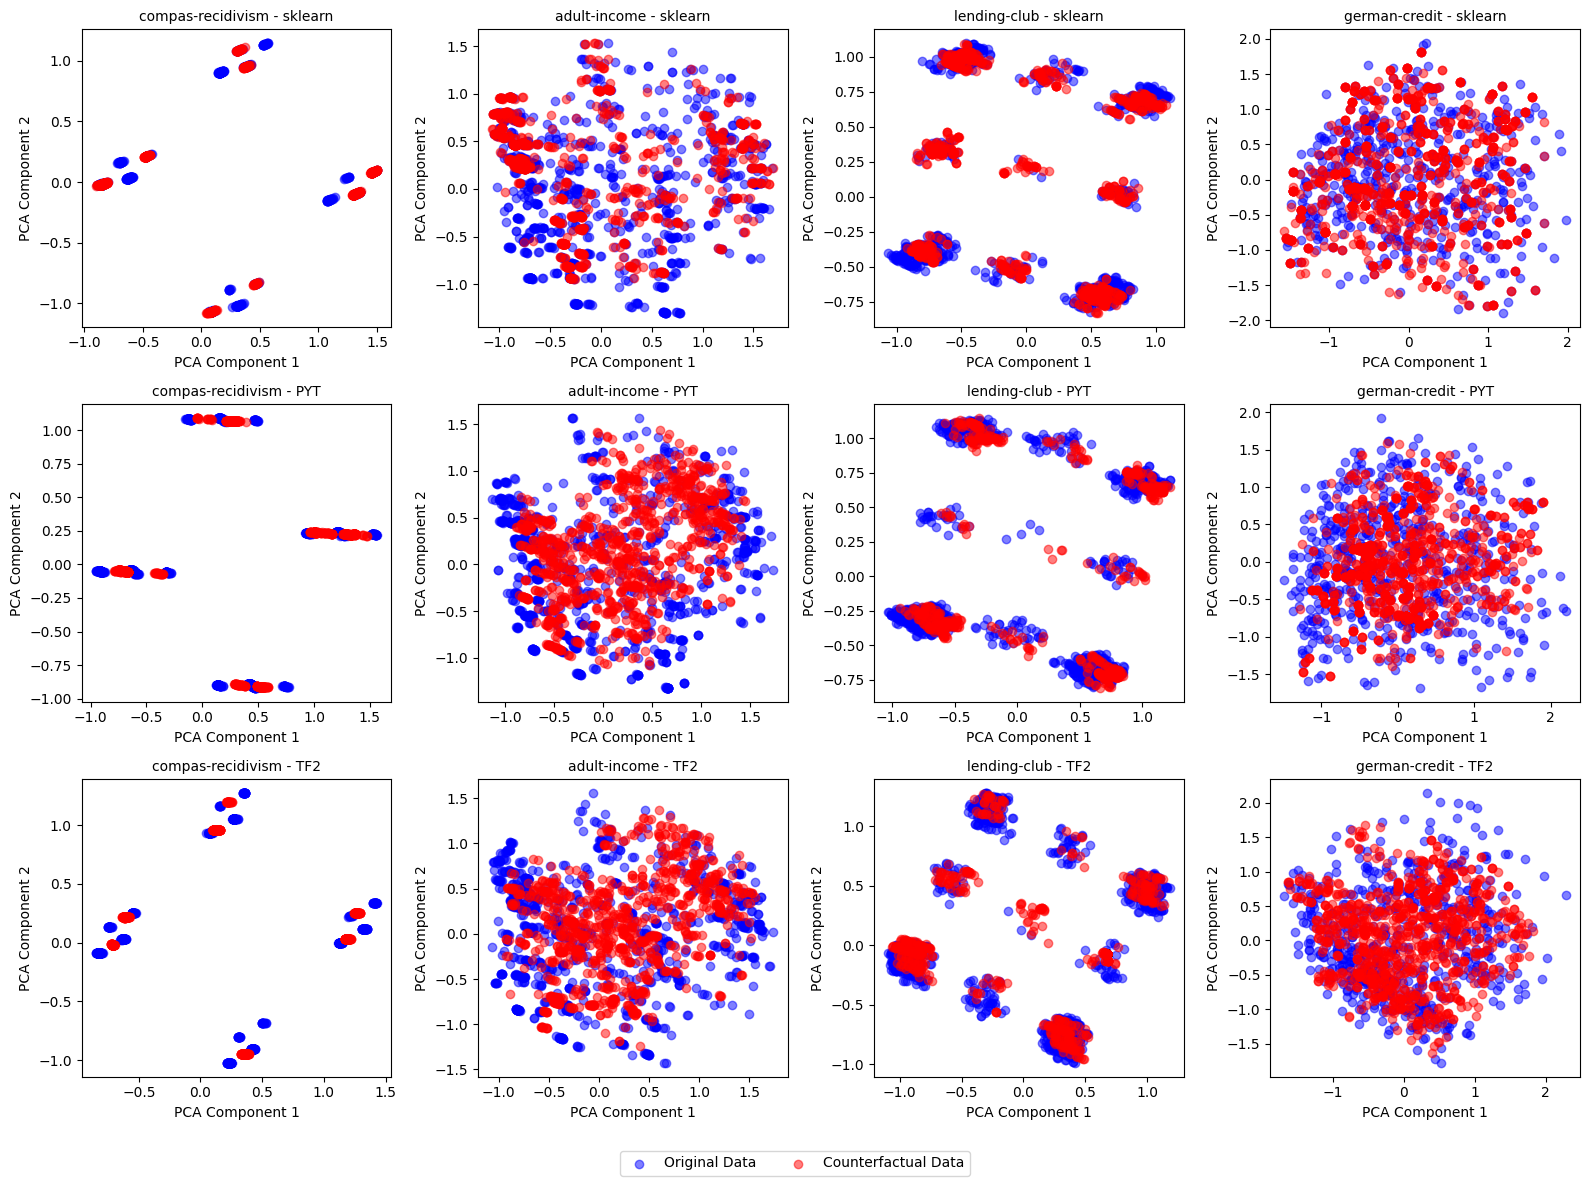

In [149]:
from sklearn.decomposition import PCA

dataset_to_col = {
    "compas-recidivism": 0,
    "adult-income": 1,
    "lending-club": 2,
    "german-credit": 3
}

backend_to_row = {
    "sklearn": 0,
    "PYT": 1,
    "TF2": 2
}


all_datasets = {
    "compas-recidivism": {
        "data": helpers.load_compas_dataset(),
        "target": "twoyearrecid"
    },
    "adult-income": {
        "data": helpers.load_adult_income_dataset(),
        "target": "income"
    },
    "lending-club": {
        "data": helpers.load_lending_club_dataset(),
        "target": "loan_status"
    },
    "german-credit": {
        "data": helpers.load_german_credit_dataset(),
        "target": "credit_risk"
    }
}

root_dir = 'cfe_datasets'
cfe_files_list = os.listdir(root_dir)

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))


all_handles, all_labels = None, None

for file_name in cfe_files_list:
    
    parts = file_name.split('_')
    dataset_name = parts[0]
    backend_name = parts[1].replace('.csv', '')

    row = backend_to_row[backend_name]
    col = dataset_to_col[dataset_name]
    ax = axes[row, col]

    original_data = all_datasets[dataset_name]["data"]
    target_name = all_datasets[dataset_name]["target"]

    n = 500
    if dataset_name == 'german-credit':
        n = 300
    _0_original_samples = original_data[original_data[target_name] < 0.5].sample(n=n)
    _1_original_samples = original_data[original_data[target_name] >= 0.5].sample(n=n)
    original_sample = pd.concat([_0_original_samples, _1_original_samples], ignore_index=True)

    orig_cont_feats = (
        original_sample
        .select_dtypes(include=[np.number])
        .columns
        .difference([target_name])
        .tolist()
    )

    orig_data_class = dice_ml_x.Data(
        dataframe=original_sample,
        continuous_features=orig_cont_feats,
        outcome_name=target_name
    )

    cfe_data = pd.read_csv(os.path.join(root_dir, file_name))
    combined_data = pd.concat([original_sample, cfe_data], ignore_index=True)
    
    combined_data_class = dice_ml_x.Data(
        dataframe=combined_data,
        continuous_features=orig_cont_feats,
        outcome_name=target_name
    )

    combined_data_ohe = combined_data_class.get_ohe_min_max_normalized_data(combined_data)
    orig_len = len(original_sample)
    orig_sample_ohe = combined_data_ohe.iloc[:orig_len]
    cfe_data_ohe = combined_data_ohe.iloc[orig_len:]

    pca = PCA(n_components=2)
    pca.fit(orig_sample_ohe)

    original_sample_2d = pca.transform(orig_sample_ohe)
    cfe_data_2d = pca.transform(cfe_data_ohe)

    cfe_cont_feats = (
        cfe_data
        .select_dtypes(include=[np.number])
        .columns
        .difference([target_name])
        .tolist()
    )
    

    sc1 = ax.scatter(
        original_sample_2d[:, 0],
        original_sample_2d[:, 1],
        color='blue',
        alpha=0.5,
        label='Original Data'
    )

    sc2 = ax.scatter(
        cfe_data_2d[:, 0],
        cfe_data_2d[:, 1],
        color='red',
        alpha=0.5,
        label='Counterfactual Data'
    )

    ax.set_title(f"{dataset_name} - {backend_name}", fontsize=10)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

    if all_handles is None and all_labels is None:
        all_handles, all_labels = ax.get_legend_handles_labels()

if all_handles is not None and all_labels is not None:
    fig.legend(
        all_handles, all_labels,
        loc='lower center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.01)
    )

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## Models' accuracies on all four datasets

We trained two types of model with three different frameworks. Firstly, a tree model is created by using sci-kit learn framework's RandomForestClassifier with the datasets with default settings. The other two models are created with PyTorch and TensorFlow frameworks. These neural networks have two layers and the architecture is same as present in the DiCE repository as follows:

\begin{equation}
\tag{3}
Linear(number\_of\_features, 20) → ReLU → Linear(20, 1) → Sigmoid
\end{equation}

While training the neural networks following hyperparameters are used:
- Learning rate: 0.001
- Number of epochs: 10
- Train dataset size: Dataset size * 80%
- Test dataset size: Dataset size * 20%
- Number of batches for training dataset: 16
- Number of batches for test dataset: 4
- Optimizer: Adam

In [18]:
# Accuracy table for each dataset

from IPython.display import display
import pandas as pd

accuracy_data = {
    dataset: {
        model: {
            'accuracy':  f"{round(details['accuracy'] * 100, 2)}%" 
        }
        for model, details in models.items()
    }
    for dataset, models in benchmarking_results.items()
}

rows = []

for dataset, models in accuracy_data.items():
    for model_name, model_info in models.items():
        row = {
            'Dataset': dataset,
            'Model': 'Random Forest Classifier' if model_name == 'sklearn' else f'Neural Network ({model_name})',
            'Accuracy': model_info.get('accuracy'),
        }
        rows.append(row)


accuracy_df = pd.DataFrame(rows)
display(accuracy_df)
accuracy_df['Dataset'] = accuracy_df["Dataset"].mask(accuracy_df["Dataset"].duplicated(), "")
markdown_table = accuracy_df.to_markdown(index=False)
print(markdown_table)

,Dataset,Model,Accuracy
0,compas-recidivism,Random Forest Classifier,57.14%
1,compas-recidivism,Neural Network (PYT),65.79%
2,compas-recidivism,Neural Network (TF2),65.49%
3,adult-income,Random Forest Classifier,81.84%
4,adult-income,Neural Network (PYT),83.36%
5,adult-income,Neural Network (TF2),83.43%
6,lending-club,Random Forest Classifier,82.39%
7,lending-club,Neural Network (PYT),82.92%
8,lending-club,Neural Network (TF2),82.94%
9,german-credit,Random Forest Classifier,75.5%


| Dataset           | Model                    | Accuracy   |
|:------------------|:-------------------------|:-----------|
| compas-recidivism | Random Forest Classifier | 57.14%     |
|                   | Neural Network (PYT)     | 65.79%     |
|                   | Neural Network (TF2)     | 65.49%     |
| adult-income      | Random Forest Classifier | 81.84%     |
|                   | Neural Network (PYT)     | 83.36%     |
|                   | Neural Network (TF2)     | 83.43%     |
| lending-club      | Random Forest Classifier | 82.39%     |
|                   | Neural Network (PYT)     | 82.92%     |
|                   | Neural Network (TF2)     | 82.94%     |
| german-credit     | Random Forest Classifier | 75.5%      |
|                   | Neural Network (PYT)     | 77.5%      |
|                   | Neural Network (TF2)     | 78.5%      |


| Dataset           | Model                    | Accuracy   |
|:------------------|:-------------------------|:-----------|
| compas-recidivism | Random Forest Classifier | 57.14%     |
|                   | Neural Network (PYT)     | 65.79%     |
|                   | Neural Network (TF2)     | 65.49%     |
| adult-income      | Random Forest Classifier | 81.84%     |
|                   | Neural Network (PYT)     | 83.36%     |
|                   | Neural Network (TF2)     | 83.43%     |
| lending-club      | Random Forest Classifier | 82.39%     |
|                   | Neural Network (PYT)     | 82.92%     |
|                   | Neural Network (TF2)     | 82.94%     |
| german-credit     | Random Forest Classifier | 75.5%      |
|                   | Neural Network (PYT)     | 77.5%      |
|                   | Neural Network (TF2)     | 78.5%      |


As it can be seen from the table the models performed satisfying both with [Adult Income Dataset](https://archive.ics.uci.edu/dataset/2/adult) and the [Lending Club Dataset](https://www.lendingclub.com/). While models perform moderately on [German Credit Risk Dataset](https://archive.ics.uci.edu/static/public/144/statlog+german+credit+data.zip), they perform poorly on [Compas Recidivism Dataset](https://api.openml.org/data/download/22111929/dataset).

## Explainers' counterfactual generation time with different datasets

Three types of explainers are generated for counterfactual generation that are genetic, PyTorch, and TensorFlow. Counterfactuals generated by genetic algorithm are generated with a genetic algorithm creates mutations with the best counterfactuals depending on the loss value. The gradient methods use Adam optimizer with a learning rate of $0.05$ and parameterize the counterfactuals to optimize counterfactuals. During the counterfactual generation process 5 counterfactuals has been created. The table below shows time spent for counterfactual generation for each model and dataset. PYT represents a neural network model created with PyTorch and TF2 represents a neural network model created with TensorFlow framework.

| Dataset           | Model          |   Time (ms) |
|:------------------|:---------------|------------:|
| compas-recidivism | Genetic        |       10.22 |
| compas-recidivism | Gradient (PYT) |        2.69 |
| compas-recidivism | Gradient (TF2) |       30.95 |
| adult-income      | Genetic        |       49.08 |
| adult-income      | Gradient (PYT) |        7.14 |
| adult-income      | Gradient (TF2) |       43.72 |
| lending-club      | Genetic        |      110.42 |
| lending-club      | Gradient (PYT) |       17.32 |
| lending-club      | Gradient (TF2) |      200.41 |
| german-credit     | Genetic        |      217.62 |
| german-credit     | Gradient (PYT) |       10.89 |
| german-credit     | Gradient (TF2) |       61.37 |

In [19]:
# Counterfactual generation time table
time_spent_data = {
    dataset: {
        model: {
            'time': round(details['time']['gaussian'], 2)
        }
        for model, details in models.items()
    }
    for dataset, models in benchmarking_results.items()
}

rows = []

for dataset, models in time_spent_data.items():
    for model_name, model_info in models.items():
        row = {
            'Dataset': dataset,
            'Model': 'Genetic' if model_name == 'sklearn' else f'Gradient ({model_name})',
            'Time (ms)': model_info.get('time'),
        }
        rows.append(row)

time_df = pd.DataFrame(rows)
display(time_df)
markdown_table = time_df.to_markdown(index=False)
print(markdown_table)

,Dataset,Model,Time (ms)
0,compas-recidivism,Genetic,10.22
1,compas-recidivism,Gradient (PYT),2.69
2,compas-recidivism,Gradient (TF2),30.95
3,adult-income,Genetic,49.08
4,adult-income,Gradient (PYT),7.14
5,adult-income,Gradient (TF2),43.72
6,lending-club,Genetic,110.42
7,lending-club,Gradient (PYT),17.32
8,lending-club,Gradient (TF2),200.41
9,german-credit,Genetic,217.62


| Dataset           | Model          |   Time (ms) |
|:------------------|:---------------|------------:|
| compas-recidivism | Genetic        |       10.22 |
| compas-recidivism | Gradient (PYT) |        2.69 |
| compas-recidivism | Gradient (TF2) |       30.95 |
| adult-income      | Genetic        |       49.08 |
| adult-income      | Gradient (PYT) |        7.14 |
| adult-income      | Gradient (TF2) |       43.72 |
| lending-club      | Genetic        |      110.42 |
| lending-club      | Gradient (PYT) |       17.32 |
| lending-club      | Gradient (TF2) |      200.41 |
| german-credit     | Genetic        |      217.62 |
| german-credit     | Gradient (PYT) |       10.89 |
| german-credit     | Gradient (TF2) |       61.37 |


## Metrics and Sensitivity Analysis for Dice Extended


### 1. Robustness Metrics

#### Dice-Sørensen Coefficient

To evaluate robustness, the Dice-Sørensen coefficient measures the similarity between counterfactuals c1 and
c2 generated for similar input instances x1 and x2:

\begin{equation}
\tag{4}
Robustness(c_1, c_2) = \frac{2 * \lvert c_1 \cap c_2 \rvert}{\lvert c_1 \rvert + \lvert c_2 \rvert}
\end{equation}

where:
- $ c_1 $ and $ c_2 $ are binary vectors,
- $ \lvert c_1 \cap c_2 \rvert $: The number of shared (overlapping) features between c1 and c2,
- $ \lvert c_1 \rvert $ and $ \lvert c_2 \rvert $: The total number of features in each counterfactual.

#### Input Perturbation and Stability

Stability under input perturbation measures the solution variance when slight perturbations are introduced
to the input instance. The procedure includes the following steps:

1) **Apply Gaussian Noise:** Perturb the input $x$ by adding Gaussian noise $\delta$ to create perturbed inputs
$x'$:

\begin{equation}
\tag{5}
x' = x + \delta, \quad \delta \sim \mathcal{N}(0, \sigma^2)
\end{equation}

where $\sigma$ is the standard deviation of the noise (e.g., $\sigma = 0.01$).

2) **Generate Counterfactuals:** Generate counterfactual explanations $c_i$ for the original input $x$ and $c_i'$ for the perturbed input $x'$.

3) **Measure Stability:** Compare counterfactuals using a distance metric, such as the Euclidean distance:

\begin{equation}
\tag{6}
Stability = \frac{1}{n} \sum_{i=1}^{n} dist(c_i, c_i')
\end{equation}

where:

\begin{equation}
\tag{7}
dist(c_i, c_i') = \sqrt{\sum_{j=1}^{d} (c_{ij} - c_{ij}')^2}
\end{equation}

$n$ is the total number of input instances, $c_i$ is the counterfactual for the original input, and $c_i'$ is the counterfactual for the perturbed input.

In the section below we will do the required computation to calculate the stability of the counterfactuals. Firstly we pick an instance from the dataset which is $x$ and generate counterfactuals to it. Subsequently, we perturb $x$ and obtain $x'$ and generate counterfactuals also for it.

In [25]:
with open('benchmarking_final_results.pkl', 'rb') as res_file:
    benchmarking_results = pickle.load(res_file)

In [ ]:
lending_df = helpers.load_lending_club_dataset()
target = lending_df['loan_status']
train_dataset, test_dataset, y_train, y_test =train_test_split(lending_df, target,
                                                               test_size=0.2, random_state=42,
                                                               stratify=target)
dummy_state_dict = torch.load(benchmarking_results['lending-club']['PYT']['model_path'])
dummy_state_dict = {f'model.{key}': value for key, value in dummy_state_dict.items()}
in_features = dummy_state_dict['model.0.weight'].shape[1]
model_path = benchmarking_results['lending-club']['PYT']['model_path']
model = neuralnetworks.PYTModel(in_features)
model.load_state_dict(dummy_state_dict)

cont_feats = lending_df.select_dtypes(include=[np.number]).columns.difference(['loan_status']).tolist()
d = dice_ml_x.Data(dataframe=train_dataset, continuous_features=cont_feats, outcome_name='loan_status')
gaussian_kwargs = {}
m = dice_ml_x.Model(model=model.model, backend='PYT', func='ohe-min-max')
exp = dice_ml_x.DiceX(d, m, method="gradient")

x_train, x_test = train_dataset.drop(columns=['loan_status']), test_dataset.drop(columns=['loan_status'])

x = x_test[1:2]

dice_exp = exp.generate_counterfactuals(x, total_CFs=10, desired_class="opposite",
                                        perturbation_method="gaussian", robustness_weight=10.0,
                                        **gaussian_kwargs)

dice_exp.visualize_as_dataframe(show_only_changes=False)
C = dice_exp.to_dataframe()

  0%|          | 0/1 [00:00<?, ?it/s]/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X/dice_ml_x/explainer_interfaces/dice_pytorch.py:407: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:34.)
  binned_indices = torch.bucketize(col_vals, edges, right=False) - 1
100%|██████████| 1/1 [00:09<00:00,  9.49s/it]

Diverse Counterfactuals found! total time taken: 00 min 09 sec
Query instance (original outcome : 0.7739999890327454)


,employment_years,num_open_credit_acc,annual_income,loan_grade,credit_history,purpose,home,addr_state,loan_status
0,5,12,175000.0,F,16.5,purchase,MORTGAGE,PA,0.774



Diverse Counterfactual set (new outcome: 0.0)


,employment_years,num_open_credit_acc,annual_income,loan_grade,credit_history,purpose,home,addr_state,loan_status
0,1,44,181195.8,A,36.2,purchase,MORTGAGE,VT,0
1,0,12,162047.3,G,3.0,purchase,MORTGAGE,ID,0
2,0,38,105629.1,F,57.1,purchase,MORTGAGE,VT,0
3,0,44,139212.2,G,16.5,purchase,MORTGAGE,ID,0
4,0,21,4080.0,G,26.7,purchase,MORTGAGE,VT,0
5,0,44,4080.0,F,3.0,purchase,MORTGAGE,ID,0
6,0,44,342382.7,G,26.4,purchase,MORTGAGE,ID,0
7,0,34,447068.7,G,6.5,purchase,MORTGAGE,ID,0
8,0,25,251422.9,G,16.5,purchase,MORTGAGE,ID,0
9,5,44,559195.0,A,16.5,purchase,MORTGAGE,VA,0


In [ ]:
x_ohe = d.get_ohe_min_max_normalized_data(x)
print("x ohe is -> \n", x_ohe)
cat_cols = d.get_encoded_categorical_feature_indexes()
print("categorical column indices are -> ", cat_cols)
cat_cols = [col for group in cat_cols for col in group]
continuous_feature_indexes = list(set(list(range(len(d.get_ohe_min_max_normalized_data(x).columns)))) - set(cat_cols))
categorical_feature_indexes = d.get_encoded_categorical_feature_indexes()


def do_perturbation(x: pd.DataFrame):
        x_tensor = torch.tensor(x.values, dtype=torch.float32)
    
        #cfs_perturbed = torch.nn.Parameter(x_tensor.clone(), requires_grad=True)

        if continuous_feature_indexes:
            
            continuous_slice = x_tensor[:, continuous_feature_indexes]
            noise = continuous_slice * 0.1
            noise_mask = torch.zeros_like(x_tensor)
            noise_mask[:, continuous_feature_indexes] = noise
            x_tensor = x_tensor + noise_mask

        if categorical_feature_indexes:
            for cat_cols in categorical_feature_indexes:
                cat_slice = x_tensor[:, cat_cols]
                sample_size = cat_slice.shape[0]
                num_cats = cat_slice.shape[1]

                rand_idx = torch.randint(low=0, high=num_cats, size=(sample_size, ))

                cat_slice_perturbed = torch.nn.functional.one_hot(rand_idx, num_classes=num_cats).float()

                cat_mask = torch.zeros_like(x_tensor)
                cat_mask[:, cat_cols] = cat_slice_perturbed
                x_perturbed = x_tensor + cat_mask
        return x_perturbed

def generate_perturbations(x_ohe: pd.DataFrame, model: any,
                           max_iter=100, tol=1e-3, gamma=1e-2):
        x_ohe_tensor = torch.tensor(x_ohe.values, dtype=torch.float32, requires_grad=True)
        x_perturbed = do_perturbation(x_ohe)
        perturbation_optimizer = torch.optim.Adam([x_perturbed], lr=1e-3)

        prev_loss = np.inf
        for _ in range(max_iter):
            with torch.no_grad():
                model.model.eval()
                pred_i = model.model(x_ohe_tensor)
                pred_i_prime = model.model(x_perturbed)
            class_loss = torch.mean((pred_i - pred_i_prime) ** 2)
            distance = torch.norm(x_perturbed - x_ohe_tensor, p=2)
            loss = class_loss + gamma * distance

            perturbation_optimizer.zero_grad()
            loss.backward()

            perturbation_optimizer.step()
            if abs(loss.item() - prev_loss) < tol:
                break
            prev_loss = loss.item()
        return x_perturbed.detach()

x_prime_ohe_tensor = generate_perturbations(x_ohe, model)
x_prime_decoded = d.get_decoded_data(x_prime_ohe_tensor.numpy())
x_prime = d.get_inverse_ohe_min_max_normalized_data(x_prime_decoded)
x_prime['employment_years'] = x_prime['employment_years'].astype(int)
x_prime['num_open_credit_acc'] = x_prime['num_open_credit_acc'].astype(int)
print("Original instance")
display(x)
print("Perturbed instance")
display(x_prime)


x ohe is -> 
    annual_income  credit_history  employment_years  num_open_credit_acc  \
0       0.043872        0.249538               0.5             0.238095   

   loan_grade_A  loan_grade_B  loan_grade_C  loan_grade_D  loan_grade_E  \
0             0             0             0             0             0   

   loan_grade_F  ...  addr_state_SD  addr_state_TN  addr_state_TX  \
0             1  ...              0              0              0   

   addr_state_UT  addr_state_VA  addr_state_VT  addr_state_WA  addr_state_WI  \
0              0              0              0              0              0   

   addr_state_WV  addr_state_WY  
0              0              0  

[1 rows x 69 columns]
categorical column indices are ->  [[4, 5, 6, 7, 8, 9, 10], [11, 12, 13, 14], [15, 16, 17, 18], [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 

,employment_years,num_open_credit_acc,annual_income,loan_grade,credit_history,purpose,home,addr_state
24355,5,12,175000.0,F,16.5,purchase,MORTGAGE,PA


Perturbed instance


,employment_years,num_open_credit_acc,annual_income,loan_grade,credit_history,purpose,home,addr_state
0,6,13,192092.0,F,17.9,purchase,MORTGAGE,PA


In [17]:
exp = dice_ml_x.DiceX(d, m, method="gradient")
dice_exp_prime = exp.generate_counterfactuals(x_prime, total_CFs=10, desired_class="opposite",
                                        perturbation_method="gaussian", **gaussian_kwargs)
C_prime = dice_exp_prime.to_dataframe()
na_cols = C_prime.columns[C_prime.isna().any().tolist()].tolist()
C_prime[na_cols] = C_prime[na_cols].fillna(x_prime[na_cols].iloc[0])
C_prime['loan_status'] = (C_prime['loan_status'] >= 0.5).astype(int)
display(C_prime)

100%|██████████| 1/1 [00:09<00:00,  9.48s/it]

Diverse Counterfactuals found! total time taken: 00 min 09 sec


,employment_years,num_open_credit_acc,annual_income,loan_grade,credit_history,purpose,home,addr_state,loan_status
0,0,14,208966.8,F,24.4,purchase,MORTGAGE,LA,0
1,5,29,101956.5,F,33.7,purchase,MORTGAGE,LA,0
2,0,44,4080.0,F,18.8,purchase,MORTGAGE,LA,0
3,0,29,280037.0,F,57.1,purchase,MORTGAGE,LA,0
4,0,44,177652.5,F,42.2,purchase,MORTGAGE,LA,0
5,0,40,41482.0,F,57.1,purchase,MORTGAGE,LA,0
6,0,44,206635.5,F,8.8,purchase,MORTGAGE,LA,0
7,10,44,379546.0,F,3.0,purchase,MORTGAGE,LA,0
8,0,42,359847.9,F,28.7,purchase,MORTGAGE,LA,0
9,0,44,609205.2,F,17.9,purchase,MORTGAGE,LA,0


In [18]:
C_ohe_tensor = torch.tensor(d.get_ohe_min_max_normalized_data(C).values, dtype=torch.float32)
C_prime_ohe_tensor = torch.tensor(d.get_ohe_min_max_normalized_data(C_prime).values, dtype=torch.float32)

def compute_stability(C_set_1: torch.Tensor, C_set_2: torch.Tensor, p: int=2) -> float:
    return torch.mean(torch.cdist(C_set_1, C_set_2, p=2)).item()

stability = compute_stability(C_ohe_tensor, C_prime_ohe_tensor)
stability

2.0402534008026123

#### Result for Stability

We computed the stability metric by converting the $C$ and $C'$ into a normalized vector that are of shape (10, 70) which means there are 10 samples with 70 features. The result of the calculation of stability under input perturbation is $~2.07$. When we consider the maximum distance between two vectors of shape (10, 70) maximum distance should equal to $~8.37$

\begin{equation}
\tag{8}
\sqrt{70 \times (1 - 0)} = 8.37
\end{equation}

### 2. Counterfactual Quality Measures

#### Fidelity

Fidelity measures how often generated counterfactuals successfully change the model’s prediction:

\begin{equation}
\tag{9}
Fidelity = \frac{\sum_{i=1}^{n} \mathbf{1}(f(c_i) = y_{desired})}{n}
\end{equation}

where:

- $f$: Prediction model,
- $c_i$: Counterfactual instance,
- $y_{desired}$: Target output class,
- $n$: Total number of counterfactuals.

Since all generated counterfactuals belong to the desired class $fidelity$ of the counterfactuals is $100\%$

#### Proximity

Proximity measures the average distance between counterfactuals $c_i$ and the original inputs $x_i$:

\begin{equation}
\tag{10}
Proximity = \frac{1}{n} \sum_{i=1}^{n} dist(x_i, c_i)
\end{equation}

The Manhattan distance can be used for simplicity:

\begin{equation}
\tag{11}
dist(x_i, c_i) = \sum_{j=1}^{d} \lvert x_{ij} - c_{ij} \rvert
\end{equation}


In [146]:
x_ohe_tensor = torch.tensor(d.get_ohe_min_max_normalized_data(train_dataset[1:2]).values, dtype=torch.float32)

def compute_proximity(original_instance: torch.Tensor, C: torch.Tensor) -> float:
    return torch.mean(torch.cdist(original_instance, C, p=1)).item()

proximity = compute_proximity(x_ohe_tensor, C_ohe_tensor)
proximity

7.653975009918213

#### Result for Proximity

We computed the proximity of $x$ and $C$ we converted them into normalized and one hot encoded tensors of shape (10, 70). The resulting total proximity between the original instance and generated counterfactuals is $7.65$ which is highly acceptable when we consider the maximum Manhattan distance between these two tensors which is $70$.


#### Diversity

Diversity measures how dissimilar the counterfactuals $c_1, c_2, c_3,\ldots,c_k$ are among themselves:

\begin{equation}
\tag{12}
Diversity = \frac{1}{k(k-1)}\sum_{i_1}^{k}\sum_{j \neq i}^{} dist(c_i, c_j)
\end{equation}

where $k$ is the number of counterfactuals.

In [147]:
def compute_diversity(C_ohe: torch.Tensor):
    k = C_ohe.shape[0]
    pairwise_dist = torch.cdist(C_ohe, C_ohe, p=2)
    diversity = (torch.sum(pairwise_dist) - torch.sum(torch.diagonal(pairwise_dist))) / (k * (k - 1))
    return diversity.item()

diversity = compute_diversity(C_ohe_tensor)
diversity

1.8660491704940796

#### Result for Diversity

For the counterfactuals tensor we work with minimum diversity value is $0$ that indicates all counterfactuals are identical. For the condition that all counterfactuals are distinct that makes the diversity value maximum which is $~4.19$. The diversity value we calculated with the counterfactuals is $1.87$ which seems that counterfactuals have a moderate spread in the features space.

### 3. Sensitivity Analysis

#### Objective Function with Weights

The modified loss function in DiCE-Extended is defined as in the [equation 1](#equation-1) where:

- $yloss(f(c_i), y)$: Prediction loss for counterfactual instance $c_i$ relative to the desired outcome $y$,
- $dist(c_i, x)$: Distance metric (e.g., Euclidean or Manhattan) between the counterfactual c_i and the original input $x$,
- $dpp\_diversity(c_1,\ldots,c_k)$: Diversity loss term based on Determinantal Point Process (DPP),
- $Robustness(c_i,c_i')$: Robustness loss measuring similarity of counterfactuals under perturbations.

  The weights $\lambda_1, \lambda_2, \lambda_3$ control the balance between proximity, diversity, and robustness, respectively.

#### Sensitivity Analysis

To perform sensitivity analysis:

1) Vary the weights $\lambda_1, \lambda_2, \lambda_3$ systematically while ensuring:

\begin{equation}
\tag{13}
\lambda_1 + \lambda_2 + \lambda_3 = 1 \text{ (for normalization)}.
\end{equation}

2) Track the changes in the following metrics:

\begin{equation}
\tag{14}
P(\lambda_1, \lambda_2, \lambda_3) = Proximity,
\end{equation}

\begin{equation}
\tag{15}
D(\lambda_1, \lambda_2, \lambda_3) = Diversity,
\end{equation}

\begin{equation}
\tag{16}
R(\lambda_1, \lambda_2, \lambda_3) = Robustness,
\end{equation}

3) Measure the relationship between these metrics and the weights.

In [164]:
d.get_inverse_ohe_min_max_normalized_data(x_ohe)

,employment_years,num_open_credit_acc,annual_income,loan_grade,credit_history,purpose,home,addr_state
0,5.0,12.0,175000.0,F,16.5,purchase,MORTGAGE,PA


In [167]:
weight_grid = [(l1, l2, 1 - l1 - l2)
               for l1, l2 in itertools.product(np.linspace(0, 1, 11), repeat=2)
               if l1 + l2 <= 1]

results = []
exp = dice_ml_x.DiceX(d, m, method="gradient")
for proximity_weight, diversity_weight, robustness_weight in tqdm(weight_grid, desc="Generating Counterfactuals"):
    cf_explanations = exp.generate_counterfactuals(x, total_CFs=10, desired_class="opposite",
                                     perturbation_method="gaussian", proximity_weight=proximity_weight,
                                     diversity_weight=diversity_weight, robustness_weight=robustness_weight,
                                     **gaussian_kwargs)
    C = cf_explanations.to_dataframe()
    C_ohe = d.get_ohe_min_max_normalized_data(C)
    C_ohe_tensor = torch.tensor(C_ohe.values, dtype=torch.float32)
    proximity = compute_proximity(x_ohe_tensor, C_ohe_tensor)
    diversity = compute_diversity(C_ohe_tensor)
    C_targetless = C.drop(columns=['loan_status'])
    C_ohe_targetless = d.get_ohe_min_max_normalized_data(C_targetless)
    C_ohe_prime_tensor = generate_perturbations(C_ohe_targetless, model)
    robustness = torch.mean(torch.norm(torch.tensor(C_ohe_targetless.values, dtype=torch.float32) - C_ohe_prime_tensor, dim=1)).item()
    results.append((proximity_weight, diversity_weight, robustness_weight, proximity, diversity, robustness))

results = np.array(results)

Generating Counterfactuals:   2%|▏         | 1/66 [01:56<2:05:46, 116.09s/it]

Diverse Counterfactuals found! total time taken: 00 min 09 sec


Generating Counterfactuals:   3%|▎         | 2/66 [03:51<2:03:33, 115.83s/it]

Diverse Counterfactuals found! total time taken: 00 min 08 sec


Generating Counterfactuals:   5%|▍         | 3/66 [04:40<1:29:27, 85.20s/it] 

...

Diverse Counterfactuals found! total time taken: 00 min 07 sec


Generating Counterfactuals:  98%|█████████▊| 65/66 [57:01<00:58, 58.49s/it]

Diverse Counterfactuals found! total time taken: 00 min 07 sec


Generating Counterfactuals: 100%|██████████| 66/66 [58:32<00:00, 53.22s/it]

Diverse Counterfactuals found! total time taken: 00 min 07 sec


In [5]:
with open('weight_sensitivity_results.pkl', 'wb') as sens_file:
    pickle.dump(results, sens_file)

NameError: name 'results' is not defined

In [6]:
with open('weight_sensitivity_results.pkl', 'rb') as sens_file:
    sens_res_loaded = pickle.load(sens_file)

EOFError: Ran out of input

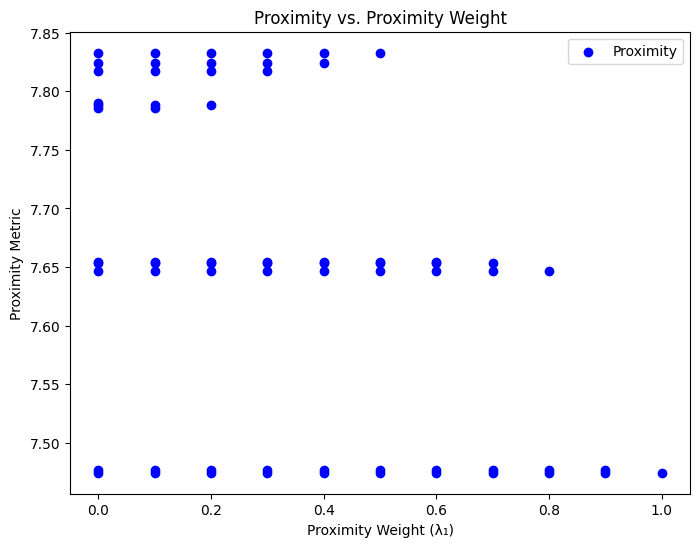

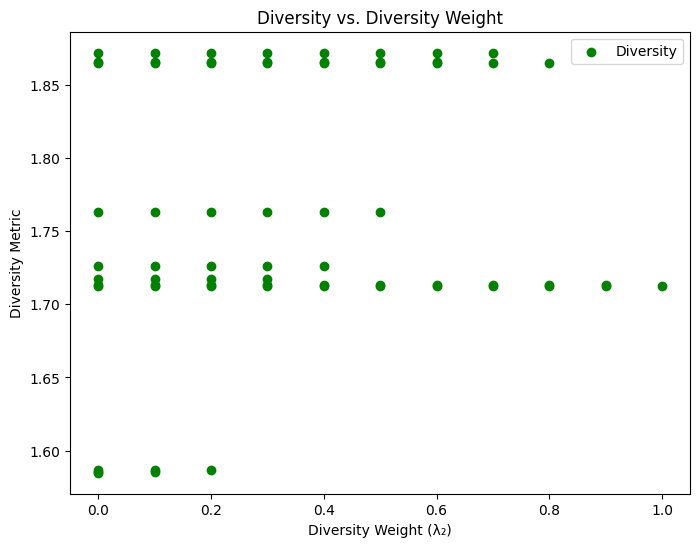

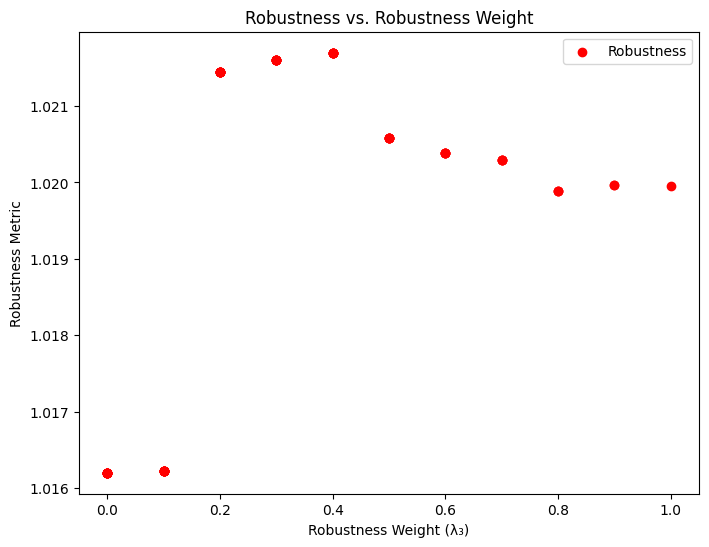

In [176]:
columns = ['proximity_weight', 'diversity_weight', 'robustness_weight', 'proximity', 'diversity', 'robustness']
results_df = pd.DataFrame(results, columns=columns)

# Plot proximity vs. proximity weight
plt.figure(figsize=(8, 6))
plt.scatter(results_df['proximity_weight'], results_df['proximity'], c='blue', label='Proximity')
plt.title('Proximity vs. Proximity Weight')
plt.xlabel('Proximity Weight (λ₁)')
plt.ylabel('Proximity Metric')
plt.legend()
plt.show()

# Plot diversity vs. diversity weight
plt.figure(figsize=(8, 6))
plt.scatter(results_df['diversity_weight'], results_df['diversity'], c='green', label='Diversity')
plt.title('Diversity vs. Diversity Weight')
plt.xlabel('Diversity Weight (λ₂)')
plt.ylabel('Diversity Metric')
plt.legend()
plt.show()

# Plot robustness vs. robustness weight
plt.figure(figsize=(8, 6))
plt.scatter(results_df['robustness_weight'], results_df['robustness'], c='red', label='Robustness')
plt.title('Robustness vs. Robustness Weight')
plt.xlabel('Robustness Weight (λ₃)')
plt.ylabel('Robustness Metric')
plt.legend()
plt.show()

As it can be seen from the charts proximity and diversity are not sensitive to changes in $\lambda_1$ and $\lambda_2$. On the other hand, robustness seems to be sensitive to changes in $\lambda_3$

In [184]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_normalize = ['proximity', 'diversity', 'robustness']

results_normalized_df = results_df.copy().__deepcopy__()

results_normalized_df[cols_to_normalize] = scaler.fit_transform(results_normalized_df[cols_to_normalize])

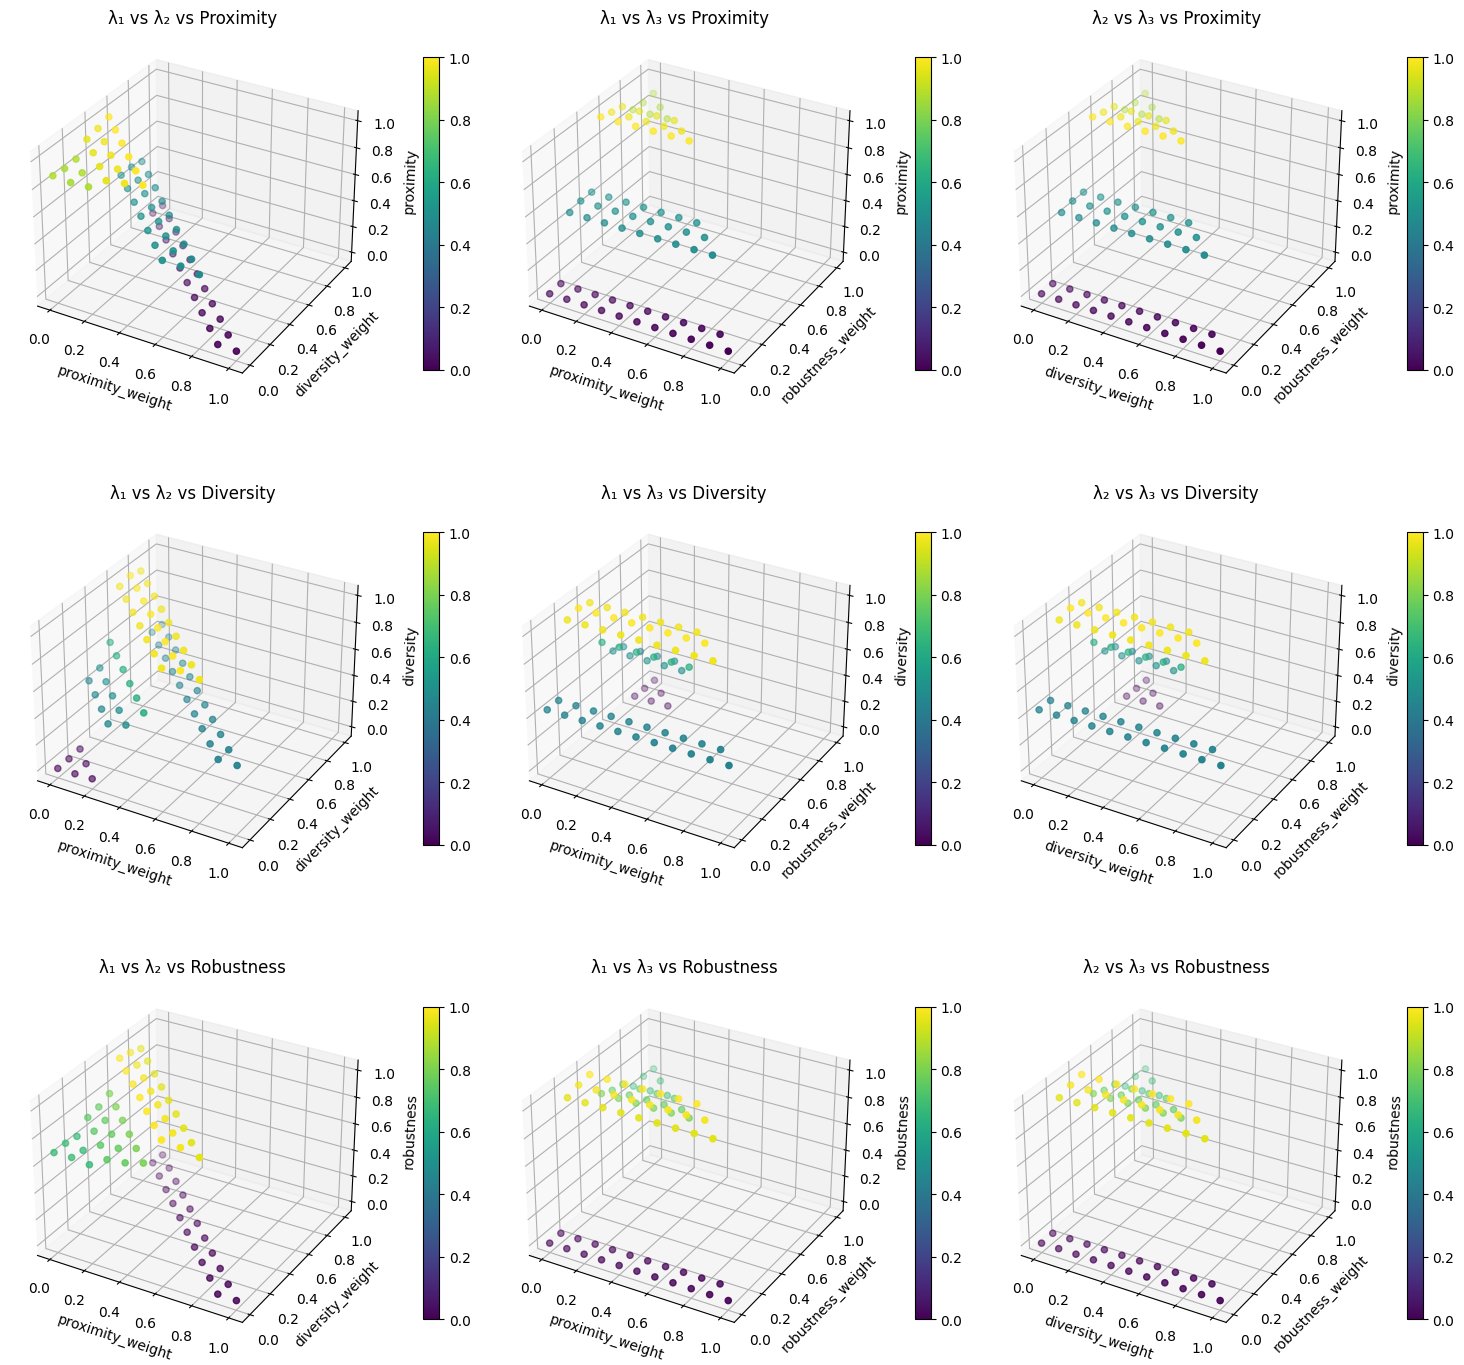

In [191]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15), subplot_kw={'projection': '3d'})

combinations = [
    ('proximity_weight', 'diversity_weight', 'proximity'),
    ('proximity_weight', 'robustness_weight', 'proximity'),
    ('diversity_weight', 'robustness_weight', 'proximity'),
    ('proximity_weight', 'diversity_weight', 'diversity'),
    ('proximity_weight', 'robustness_weight', 'diversity'),
    ('diversity_weight', 'robustness_weight', 'diversity'),
    ('proximity_weight', 'diversity_weight', 'robustness'),
    ('proximity_weight', 'robustness_weight', 'robustness'),
    ('diversity_weight', 'robustness_weight', 'robustness'),
]

titles = [
    'λ₁ vs λ₂ vs Proximity',
    'λ₁ vs λ₃ vs Proximity',
    'λ₂ vs λ₃ vs Proximity',
    'λ₁ vs λ₂ vs Diversity',
    'λ₁ vs λ₃ vs Diversity',
    'λ₂ vs λ₃ vs Diversity',
    'λ₁ vs λ₂ vs Robustness',
    'λ₁ vs λ₃ vs Robustness',
    'λ₂ vs λ₃ vs Robustness',
]

for ax, (x, y, z), title in zip(axes.flatten(), combinations, titles):
    sc = ax.scatter(results_normalized_df[x], results_normalized_df[y], results_normalized_df[z],
                    c=results_normalized_df[z], cmap='viridis')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)

plt.tight_layout()
plt.show()